# Planet: a knob in, a world out

*A guided what-if over the capstone — the latitudinal climate of a planet, the bands of life it sets,
and the winds it organises.*

You turn two planetary knobs — **how bright the sun is** and **how much greenhouse gas is in the
air** — and the model hands back a whole world: a pole-to-equator **temperature profile**, the
**bands of life** that profile permits, and the **winds** rotation spins out of it. This notebook
walks that chain end to end and lets you turn the knobs: the solar constant, the greenhouse (OLR)
offset, the efficiency of heat transport.

Every number here comes from a function **validated in isolation** (`planet/…`, each with
its own test triad — an analytic limit, a conservation/consistency law, a published benchmark). The
notebook is a *thin skin* (per [ADR 0002](../docs/decisions/0002-visualization-and-ux.md)): each
compute cell calls the headless module directly, then `ipywidgets` sliders re-run that same code
live. The figures *consume* validated arrays — they are reach, not evidence.

The arc — the climate, the bifurcation it hides, the life it sets, and the winds it drives:

1. **The climate spine** — the latitudinal **energy-balance model** → the temperature profile
   `T(φ)` (`ebm`, `albedo`).
2. **The Snowball bifurcation** — one knob (the sun), **two stable climates**, a catastrophic jump
   (`demo_snowball`).
3. **Climate → habitability** — precip + the **Whittaker classifier** → the **biome map**
   (`precip`, `biomes`, `demo_biomes`).
4. **The winds** — a **second, independent solver engine**, a rotating **shallow-water** solver:
   geostrophic adjustment and a westward Rossby wave (`circulation`, `demo_shallowwater`).
5. **The emergent jet** — couple the climate back to the fluid: its temperature gradient forces the
   flow and a **midlatitude jet emerges** (`coupler`, `demo_coupler`).
6. **The deep end** — the interactive 3-D globe (`planetmap`), and what comes next up the GCM
   staircase.
7. **Design your own world** — every knob at once, and **save / load** a planet to a file
   (`planet_spec`).
8. **Up the staircase** — the staircase §6 teases, *climbed*: four **research rungs beyond rung 0**
   that these same engines actually reach — a **moist water cycle**, emergent **polar amplification**,
   **baroclinic eddy turbulence**, and the **logarithmic CO₂ law** behind the §1 greenhouse knob
   (`moist`, `moist_ebm`, `baroclinic_qg`, `radiation`).

> This simulator is built on **two separate, independently-validated solver engines**. The climate
> half **reuses a general-purpose 1-D diffusion solver (`engines/diffusion`), unchanged** — the very
> same solver works for *any* diffusion problem, and a planet's **pole-to-equator heat transport** is
> simply one more setting for it. The winds half **adds the second engine**, a rotating shallow-water
> fluid solver (§4–5), which shares no machinery with the first. Units are **SI / climlab-conventional**:
> W m⁻², °C, precipitation in cm/yr, and `x = sin φ` (the equal-area latitude coordinate).


## Setup

Imports + the inline backend. The bootstrap walks up to the repo root so `planet…` imports
whether you launched Jupyter from the repo root or from `planet/`. Needs the `viz` +
`notebook` extras: `pip install -e .[viz,notebook]`.

> **How to read this notebook — three depths, your pick.** Read the **narrative** above each figure
> for the story (no math needed); **turn the sliders** to build intuition by watching the knobs move
> the world; and expand the **▸ _Going deeper_** block in each section for the derivations, the
> method choices, and the honest scope edges. Skip any layer you don't want — the story stands on
> its own. **Run → Run All Cells** first.

> **The code in every section is hidden by default** so the explanations and figures lead. To
> **see** a cell's code, click the **`⋯` placeholder** (or the slim blue bar) at the cell's left
> edge; to **hide** it again, **right-click the cell → _Hide Cell Code_** — or press
> **Ctrl + Shift + C** and run **_Hide Cell Code_** from the Command Palette. And anywhere below,
> hovering a <abbr title="like this — a dotted-underlined term reveals a plain-language definition when you hover over it">dotted-underlined term</abbr> pops a plain-language definition.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

# Make `planet…` importable regardless of the launch directory.
for _root in (Path.cwd(), *Path.cwd().parents):
    if (_root / "pyproject.toml").exists():
        if str(_root) not in sys.path:
            sys.path.insert(0, str(_root))
        break

from dataclasses import replace

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact

from planet import ebm, albedo, precip, biomes
from planet import demo_snowball, demo_biomes, demo_shallowwater, demo_coupler
from planet.albedo import EBMParams, present_day_climate
from planet.ebm import A_OLR, S0_EARTH, D_TRANSPORT, T_FREEZE
from planet.biomes import Biome, BIOME_NAMES
from planet.plots import (profile_axes, snowball_figure, biomes_figure,
                                   shallowwater_figure, coupler_figure)

print(f"present-day defaults:  S₀ = {S0_EARTH:.1f} W/m²,  OLR offset A = {A_OLR:.0f} W/m²,  "
      f"transport D = {D_TRANSPORT:.3f} W/m²/K")


from planet.explain import Knobs, diagnose, explain
from IPython.display import display, HTML

# A coloured, full-width slider style so the knob labels never truncate (and the handle isn't white).
KNOB_STYLE = {"description_width": "initial", "handle_color": "#f0a500"}

# Present-day Earth — the baseline every what-if explanation is measured against (computed once).
_BASE_DIAG = diagnose(demo_biomes.compute(EBMParams()))


def explain_panel(result, **knobs):
    """Render planet.explain's *what changed + why* for a what-if `result` (a demo_biomes.BiomeResult).

    `knobs` are the knob values that produced it (S0, A, D, obliquity_deg, T_star, size — any omitted
    default to present-day Earth). The same rule-based prose the browser what-if bakes in, at two
    depths: a headline + one-line causal chain, and a click-to-open fuller mechanism.
    """
    ex = explain(Knobs(**knobs), _BASE_DIAG, diagnose(result))
    display(HTML(
        "<div style='border-left:4px solid #f0a500;padding:.15rem .9rem;margin:.5rem 0'>"
        f"<div style='font-weight:700;font-size:1.06em'>{ex.headline}</div>"
        f"<div>{ex.oneline}</div>"
        "<details style='margin-top:.4rem'>"
        "<summary style='cursor:pointer'>Why — the fuller mechanism</summary>"
        f"<div style='margin-top:.3rem'>{ex.paragraph}</div></details></div>"))


present-day defaults:  S₀ = 1365.2 W/m²,  OLR offset A = 210 W/m²,  transport D = 0.555 W/m²/K


## 1 — The climate spine: the energy-balance model

The planet's climate is one equation, balanced at every latitude:

$$C\,\frac{\partial T}{\partial t} = \underbrace{D\,\frac{\partial}{\partial x}\!\Big[(1-x^2)\frac{\partial T}{\partial x}\Big]}_{\text{heat transport (the diffusion engine)}} + \underbrace{S(x)\,(1-\alpha)}_{\text{absorbed sunlight}} - \underbrace{(A + B\,T)}_{\text{outgoing longwave}},\qquad x=\sin\varphi.$$

**In words:** at every latitude, the rate the temperature changes (left) equals what comes *in* — heat
carried sideways by the atmosphere and ocean, plus the sunlight actually absorbed — minus what leaves,
the infrared the planet radiates to space. Let it run until nothing changes any more and the leftover
profile is the **equilibrium** climate `T(φ)` — the curve every figure in this section draws.

**Reading the equation, term by term** (technical terms in the prose below are dotted-underlined —
hover any of them for a one-line gloss):

- $T(\varphi)$ — the **temperature at each latitude**; $\varphi$ (*phi*) is latitude, 0° at the equator
  and 90° at the pole. So `T(φ)` is just "temperature as you walk from equator to pole."
- $x=\sin\varphi$ — an **equal-area** stand-in for latitude: equal steps in $x$ cover equal *areas* of
  the globe, which keeps global averages honest (a degree near the pole is a far smaller slice of
  planet than a degree at the equator).
- $\partial T/\partial t$ — **how fast the temperature is changing** in time. At **equilibrium** this is
  zero: energy in = energy out, and `T(φ)` has stopped moving. That settled profile is the "climate."
- $C$ — the surface **heat capacity**: the energy it takes to warm the surface by one degree (the
  climate's thermal inertia). It sets only *how quickly* the planet reaches equilibrium, not the final
  climate.
- $D$ — the **heat-transport efficiency**: one lumped number for how vigorously winds and currents move
  heat from the warm equator toward the cold poles. Higher $D$ → a flatter, more even planet.
- $(1-x^2)$ — the **sphere's geometry**: transport weakens toward the poles (where the meridians crowd
  together) and vanishes exactly at the pole.
- $S(x)$ — the **incoming sunlight** at each latitude (strong at the equator, glancing at the poles);
  its overall brightness is set by the **solar constant** $S_0$.
- $\alpha$ (*alpha*) — the **albedo**, the fraction of sunlight reflected straight back (bright snow/ice
  ≈ 0.6, dark ocean ≈ 0.3). So $S(x)\,(1-\alpha)$ is the sunlight actually *absorbed*.
- $A + B\,T$ — the **outgoing longwave radiation** (OLR), the infrared heat the planet glows away to
  space. $A$ is the baseline offset — set largely by greenhouse gases, so **more CO₂ → a lower $A$ → a
  warmer planet** — and $B$ is how much that escaping heat grows per degree of warming.

The **transport** term is a *diffusion equation* on the sphere — the same smoothing-out math that
spreads heat along a metal bar or a drop of ink through water (its mathematical class is
<abbr title="parabolic: the family of diffusion/heat equations — they smooth gradients out over time and are stable to step forward implicitly">parabolic</abbr>). So it runs on the project's reusable 1-D diffusion solver (`engines/diffusion`),
**unchanged**, here carrying heat equator→pole with **insulated poles** (no heat leaks out the ends, so
the term only *redistributes* warmth). The sunlight-and-radiation part isn't plain diffusion, so it is
layered *around* the engine by <abbr title="operator splitting: advance two coupled processes — here transport then radiation — in alternating sub-steps within one time step">operator splitting</abbr> — advance transport, then radiation, in alternating sub-steps of
each time step.

The one **nonlinear** piece is the <abbr title="ice-albedo feedback: a self-reinforcing loop — ice reflects sunlight, which cools the surface, which grows yet more ice">ice-albedo feedback</abbr>: the albedo jumps to its bright
ice value wherever the surface freezes (below −10 °C), so a colder pole reflects more sunlight and gets
colder still. To *see* it, the notebook overlays the **same climate with the feedback switched off**
(the albedo never flips to ice). Where the planet is unfrozen the two curves nearly coincide; the
**iced pole pulls the real profile far below** — that gap is the feedback's bite. Warm the planet until
the ice cap vanishes and the curves **merge exactly**; dim it and they split. (In that no-feedback
limit the EBM has an exact closed form — **North's 1975 two-mode solution** — which the engine
reproduces to 2nd order: the tight validation leg behind this panel.) The dramatic consequences of the
feedback are §2's job.

Turn the knobs: brighter/dimmer sun `S₀`, more/less greenhouse (a **lower** OLR offset `A` ≈ more CO₂ →
warmer), and the heat-transport efficiency `D` (higher `D` flattens the equator-to-pole contrast).

<details>
<summary><b>🌡 Going deeper — the engine reuse, the Strang split, and North's analytic anchor</b> &nbsp;(click to expand)</summary>

The EBM is not a new solver — it is the **`engines/diffusion` spine reused, unchanged, in a new physical setting.** Latitudinal heat transport on a sphere *is* a diffusion equation, and it maps onto the sealed parabolic solver exactly: in heat mode the state is the temperature `u = T`, and the engine's **spatially-varying diffusivity** — its transport strength is allowed to differ at every latitude — is `D_eng(x) = (D/C)·(1 − x²)`. That `(1 − x²)` factor is the sphere's geometry — it **vanishes at the pole** (`x = sin φ → 1`, where the meridians converge) — and the boundary condition is **insulated at both ends** (`Neumann(0)`: the equator by hemispheric symmetry, the pole by no-flux through a point). Insulated walls are the engine's exact conservation BC, so the transport term *only redistributes* heat: the global mean `∫₀¹ T dx` is conserved structurally, a property the solver carries for free.

**The radiation can't be the engine's source.** The outgoing-longwave term `−(A + B·T)` is linear in `T`, but the absorbed sunlight `S(x)(1 − α(T))` is a *nonlinear pointwise* function of temperature (the albedo flips where the surface freezes), and the engine's source slot only accepts `S(x, t)`, not `S(u)`. So the radiation is composed *around* the engine by **Strang operator splitting** — the standard way to bolt a linear, pointwise term (here the radiation) onto a diffusion solver without modifying the solver itself. Each step is: a half-step of the local radiation ODE, a full implicit transport step (the engine's solver, untouched), then a second radiation half-step. The local ODE has, with α held fixed over the substep, the **exact** exponential solution `T ← T_eq + (T − T_eq)·exp(−½Δt·B/C)` with `T_eq = (S(1−α) − A)/B` — so the composition inherits the engine's unconditional stability, with a 2nd-order-in-Δt splitting error. So this section reuses *both* the bare engine and the splitting pattern that wraps it.

**The analytic anchor.** Switch the ice feedback off (constant albedo) and the EBM has an exact closed form — **North's 1975 two-mode solution** — which the engine reproduces to 2nd order in Δx. That is the tight validation leg behind the §1 panel: the on↔off gap you see *is* the ice-albedo feedback, not numerics, which is why this is the one cell that does **not** coarsen the time step. Two orthogonal, user-selectable knobs form a mutual cross-check web: the **face representation** (`harmonic` accepts a ~0.1 °C polar bias where `(1−x²)` vanishes; `exact` pre-distorts the cell values so the engine's harmonic-mean face *reproduces* the true coefficient, → ~0.01 °C), and the **steady-state method** (`relax` is the Strang split above — the only path that handles the nonlinear feedback, so the Snowball sweep uses it; `direct` is a dt-free linear solve, splitting-error-free but valid only for a constant-albedo field, so it is the reference the no-feedback North check rides).

**The named scope edge** is the outgoing-longwave law itself: `A + B·T` is a *linearized parameterization* of the planet's radiation to space (climlab's defaults), not a spectrally-resolved radiative-transfer calculation — a deliberate v1 reduction, named not hidden.

Every constant below is a *cited* value (climlab's published defaults), **not a notebook fit** — here is what each one means in plain terms:

| Symbol | Value | What it is, in plain terms |
|---|---|---|
| `S₀` | 1365.2 W/m² | **Solar constant** — the sunlight power landing on one square metre held face-on to the Sun at Earth's distance, *before* any is reflected. Brighten it and the whole planet warms. |
| `A`, `B` | 210 W/m², 2 W/m²/K | **Outgoing-longwave (OLR) law** `A + B·T` — the infrared heat the planet radiates to space. `A` is the baseline (a *lower* `A` ≈ more greenhouse gas → warmer); `B` is the extra escape per °C. A deliberately simple stand-in for a full wavelength-by-wavelength radiation calculation. |
| `D` | 0.555 W/m²/K | **Transport efficiency** — how fast heat is carried equator→pole by winds and currents (the diffusion engine's coefficient). Higher `D` evens the planet out. |
| `a₀`, `a₂`, `a_ice` | 0.30, 0.078, 0.62 | **Albedo (reflectivity)** — an ice-free surface reflects `α = a₀ + a₂·P₂(x)` (a touch brighter toward the poles); a frozen surface jumps to the bright `a_ice`. |
| `T_freeze` | −10 °C | The temperature below which the surface counts as **ice** and flips to the bright albedo — the single nonlinearity that drives the Snowball (§2). |

</details>

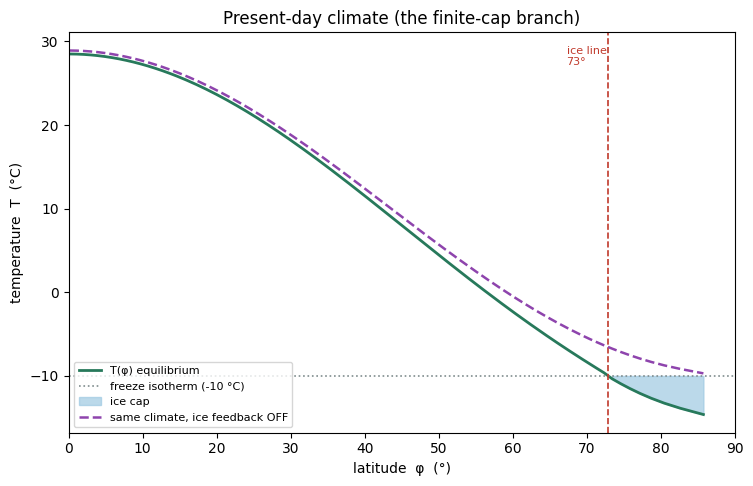

S₀ 1365 · A 210 · D 0.555  →  T̄ 14.70 °C · ice line 72.9° · net-TOA +2.0e-07 W/m²
   max |ice-on − ice-off| = 4.92 °C   (the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)


In [2]:
def climate_profile_what_if(S0=S0_EARTH, A=A_OLR, D=D_TRANSPORT):
    # Present-day EBM climate (ice feedback ON) vs the SAME climate with the feedback OFF.
    # n_tau=0.01 (fine): the steady state carries an O(Δt) operator-splitting bias, so this is the
    # one place NOT to coarsen — the on↔off gap must be the ice feedback, not numerics.
    params = EBMParams(S0=float(S0), A=float(A), D=float(D))
    ice_on = present_day_climate(params, n_tau=0.01)
    # Ice feedback OFF: push the freeze isotherm below any temperature, so α never switches to ice.
    ice_off = present_day_climate(replace(params, T_freeze=-1000.0), n_tau=0.01)
    lat = ice_on.latitude_deg()

    fig, ax = plt.subplots(figsize=(8.6, 5.2))
    profile_axes(ax, ice_on)
    ax.plot(lat, ice_off.T, "--", color="#8e44ad", lw=1.8, label="same climate, ice feedback OFF")
    ax.legend(fontsize=8, loc="lower left")
    plt.show()

    gap = float(np.max(np.abs(ice_on.T - ice_off.T)))
    print(f"S₀ {S0:.0f} · A {A:.0f} · D {D:.3f}  →  "
          f"T̄ {ice_on.global_mean_T:.2f} °C · ice line {ice_on.ice_line_lat:.1f}° · "
          f"net-TOA {ice_on.net_toa:+.1e} W/m²")
    print(f"   max |ice-on − ice-off| = {gap:.2f} °C   "
          f"(the gap IS the ice-albedo feedback; → 0 when the planet goes ice-free)")

# Direct render (static, banked in the .ipynb).
climate_profile_what_if()

In [3]:
# Live: brighten/dim the sun, add greenhouse (lower A), change the heat-transport efficiency D.
interact(
    climate_profile_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1200, max=1500, step=10,
                           description="S₀ W/m²", continuous_update=False, style=KNOB_STYLE),
    A=widgets.FloatSlider(value=A_OLR, min=190, max=220, step=2,
                          description="OLR A (lower=warmer)", continuous_update=False, style=KNOB_STYLE),
    D=widgets.FloatSlider(value=D_TRANSPORT, min=0.10, max=1.20, step=0.05,
                          description="transport D", continuous_update=False, style=KNOB_STYLE),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1500.0, mi…

## 2 — The Snowball bifurcation: one knob, two climates

Hidden inside that climate is a **bistability**. Dim the sun slowly and the ice cap creeps
equatorward — then past a threshold the ice-albedo feedback runs away and the **whole planet freezes
in a catastrophic jump** (Snowball Earth). Brighten it back and the white planet reflects so much
that it **stays frozen far past where it froze** — a wide hysteresis loop, *two stable climates for
one sun*.

This is the banked payoff and the integration test of every §1 piece (transport + the Strang-split
radiation + the feedback). It is a **parameter-continuation sweep** — ~120 equilibria, each
warm-started from the last — so it is **static, not a live slider**: a single `S₀` is a point, and
you need the whole loop to *see* the hysteresis. (The ★ is present-day Earth on the finite-cap
branch — a near-ice-free climate is also stable at today's sun.)

<details>
<summary><b>❄ Going deeper — the saddle-node bifurcation, and why it takes a continuation sweep</b> &nbsp;(click to expand)</summary>

The bistability is a **saddle-node (fold) bifurcation**. The ice-albedo feedback is *positive*: a colder pole grows more ice, which reflects more sunlight, which cools it further. Where that feedback's gain exceeds the radiative restoring (`B·T`), the steady-state curve folds back on itself — there are **three equilibria for one sun**: a warm (finite-cap) branch, a frozen (Snowball) branch, and an **unstable middle branch** between them that no time-relaxation can sit on. The two **fold points** are the catastrophic jumps: dim past the warm fold and the only equilibrium left is frozen (the runaway); brighten past the Snowball fold and the only one left is temperate (the re-melt). The loop has positive width because the white planet reflects too much to thaw at the very sun that first froze it.

**Why it must be a sweep, not a slider.** A single `S₀` solve finds *one* branch — whichever the initial guess falls into — so it can never *show* the hysteresis. The demo is a **parameter-continuation sweep**: ~120 equilibria, each **warm-started from the previous `S₀`'s equilibrium**, so the relaxation tracks whichever branch it is already on as the sun ramps down and back up. That continuation is exactly what traces out both stable branches *and* the jumps between them — and it is why this section is a *banked figure*, not an `interact()` slider: the story is the whole loop, not any single point on it.

**What is asserted tight vs loose** (the honest split). The **existence and structure** of the hysteresis — two stable branches over a band of `S₀`, a *discontinuous* freezing jump, and a re-melt at a *higher* `S₀` than the freeze — is emergent (nothing but the feedback produces it) and asserted firmly. The **exact threshold `S₀` values and the loop width** depend on the cited albedo/radiation constants, so they are asserted only in loose bands and benchmarked against climlab; the published anchor is the **Voigt–Marotzke GCM Snowball threshold of ~6–9 % dimming**. The ★ marks present-day Earth on the finite-cap branch — note that a *near-ice-free* climate is **also stable at today's sun**: the planet is bistable right now, not only in the geologic past.

</details>

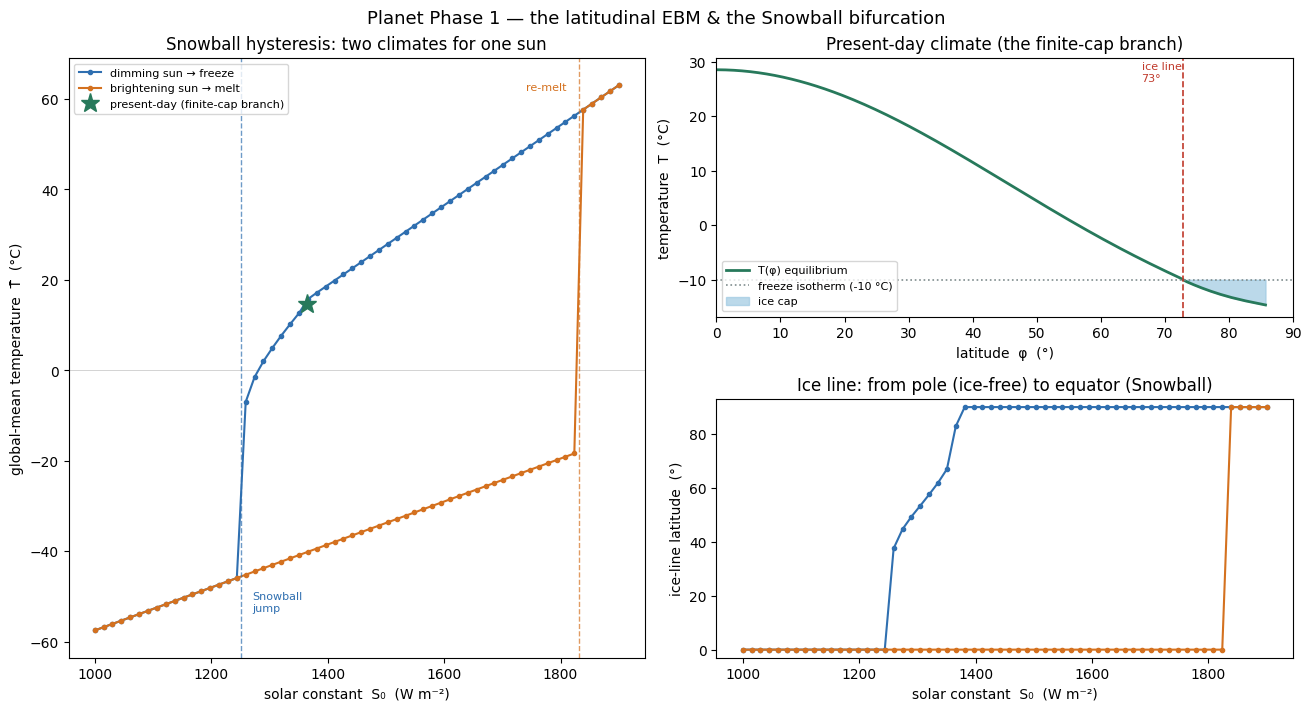

present-day:  T̄ 14.70 °C, ice line 72.9° (finite-cap branch; a near-ice-free climate is ALSO stable today)
freezes when dimmed to  S₀ ≈ 1252 W/m²  (−8.3%);  re-melts only at  S₀ ≈ 1831 W/m²   (hysteresis width 580 W/m²)
Snowball global-mean temperature: -57.5 °C  (a frozen white planet)


In [4]:
# The banked payoff: the full continuation sweep (dim → freeze, brighten → re-melt). ~3 s, static.
r = demo_snowball.compute()
snowball_figure(r.loop, r.present)
plt.show()
print(f"present-day:  T̄ {r.present.global_mean_T:.2f} °C, ice line {r.present_ice_line:.1f}° "
      f"(finite-cap branch; a near-ice-free climate is ALSO stable today)")
print(f"freezes when dimmed to  S₀ ≈ {r.freeze_S0:.0f} W/m²  (−{r.freeze_dimming_pct:.1f}%);  "
      f"re-melts only at  S₀ ≈ {r.melt_S0:.0f} W/m²   (hysteresis width {r.hysteresis_width:.0f} W/m²)")
print(f"Snowball global-mean temperature: {r.snowball_Tbar:.1f} °C  (a frozen white planet)")

## 3 — Climate → habitability: the biome map

Now the payoff the whole capstone builds toward. The climate state — the EBM temperature `T(φ)` and
a diagnostic precipitation `P(φ)` (`precip`: a circulation-set latitude pattern × a Clausius–Clapeyron
moisture amplitude) — is mapped through the **Whittaker classifier** (`biomes`) into a **biome at
every latitude**: tropical rain forest at the equator, the great deserts and savanna in the
subtropics, temperate forest in the midlatitudes, then boreal forest and tundra toward the poles.

*Planetary knobs in, bands of life out* — the simulator's whole chain delivered as one picture. And the bands **migrate as the knobs turn**: add greenhouse forcing (a CO₂ increase ≈ a
**lower** OLR offset `A`; a doubling ≈ 4 W/m²) and the tropics expand while the tundra retreats
poleward. The right panel is the *mechanism* — the Whittaker `(T, P)` plane with the planet's
equator→pole trajectory drawn through it, showing **why** the warm, dry subtropics land in desert.

<details>
<summary><b>🌿 Going deeper — the Whittaker partition (an original rule, not a traced figure), and precip = pattern × Clausius–Clapeyron</b> &nbsp;(click to expand)</summary>

**The classifier is an original, *total* partition of the `(T, P)` plane — not a digitized copy of Whittaker's figure.** This follows a deliberate principle for reproducing a published figure without copying it: a copyrighted *graphical* diagram is reproduced by an *independent* computation calibrated to it and benchmarked loosely, never traced, digitized, and redistributed. The boundary thresholds are *read off* Whittaker's diagram and pinned as cited constants; the partition is then a deterministic rule that covers the **whole** plane with no gaps — which is *why* the biome map tiles the planet and the area fractions sum to 1 (the §3 consistency leg). The partition's geometry mirrors the diagram's two physics: **cold biomes are temperature-limited**, so the tundra and boreal boundaries are *vertical* (precip-independent — nothing grows tall where it is cold enough, however wet); **warm biomes are moisture-limited**, so the boundaries *slope* — three precip thresholds, **linear in `T`**, bin the warm zone into four moisture classes (arid → semi-arid → sub-humid → humid), each threshold sitting at higher precipitation as it warms (warm air evaporates more, so a forest needs more rain). In the **temperate** band each class gets its own biome name; in the **tropical** band the two middle classes share the *seasonal forest / savanna* name.

| Temperature band | Boundary type | Biomes (dry → wet) |
|---|---|---|
| cold (`T < 3 °C`) | vertical (precip-blind) | Tundra, then Boreal forest |
| temperate (`3–20 °C`) | sloped — 4 moisture classes | Temperate grassland / desert → Woodland / shrubland → Temperate seasonal forest → Temperate rain forest |
| tropical (`T ≥ 20 °C`) | sloped — same thresholds | Subtropical desert → Tropical seasonal forest / savanna → Tropical rain forest |

**The precipitation is a *prescribed* field, not a simulated water cycle** — a named honesty flag, because neither the energy-only EBM nor the dry shallow-water engine produces rain (a real hydrological cycle is moist thermodynamics, the GCM tar pit). It is a clean separation `P(φ, T̄) = pattern(φ) · CC(T̄)`: the **pattern** is set by the general circulation (a wet equatorial ITCZ, dry subtropics ~25–30° under the descending Hadley branch — the world's great deserts — wet midlatitude storm tracks ~50°, dry poles), built as Gaussian bands with the subtropical minimum *emerging* as the trough between them; the **amplitude** is **Clausius–Clapeyron**, the ~7 %/K rise in moisture capacity, scaled by **global-mean** `T̄`. Scaling by *local* temperature instead would wrongly re-attribute the wet equator to local warmth and **over-amplify** it (a ×2.6 boost at 28 °C), breaking the calibration — so the circulation-set pattern is held fixed and only the global moisture amplitude responds to warming.

**The non-circularity guard, and the scope edges.** The validation probe points (tropical rain forest = warm + wet, tundra = cold, subtropical desert = warm + dry) are **independent canonical facts**, *not* points drawn inside lines this module invented — so the benchmark doesn't test the partition against itself. Named scope edges: **no water cycle** (precip prescribed, not derived); **band centres are fixed** — v1 intensifies the bands in place but does not *migrate* them, since true ITCZ-shift / Hadley-widening is a circulation response — *this is now built up the staircase* (the opt-in rung-1 storm-track shift, `circ_precip`, anchored on the **emergent jet latitude**, and the rung-2.x ITCZ migration, `sphere_ebm`; rung-0 keeps the fixed centres by default — see §8); **Whittaker** (annual `T, P`) is used, not **Köppen**, which needs the seasonal precip the annual-mean model doesn't produce; and the 7 %/K used here is the *moisture-capacity* rate, distinct from the **~2.5 %/K** *energy-constrained* rate that limits how fast actual global-mean precipitation can rise — *this gap is now built too* (the opt-in rung-2 **wet-get-wetter** split, `moist`, scales the global mean at the slow energy rate while the wet−dry *contrast* sharpens at the faster C–C rate — §8.1).

</details>


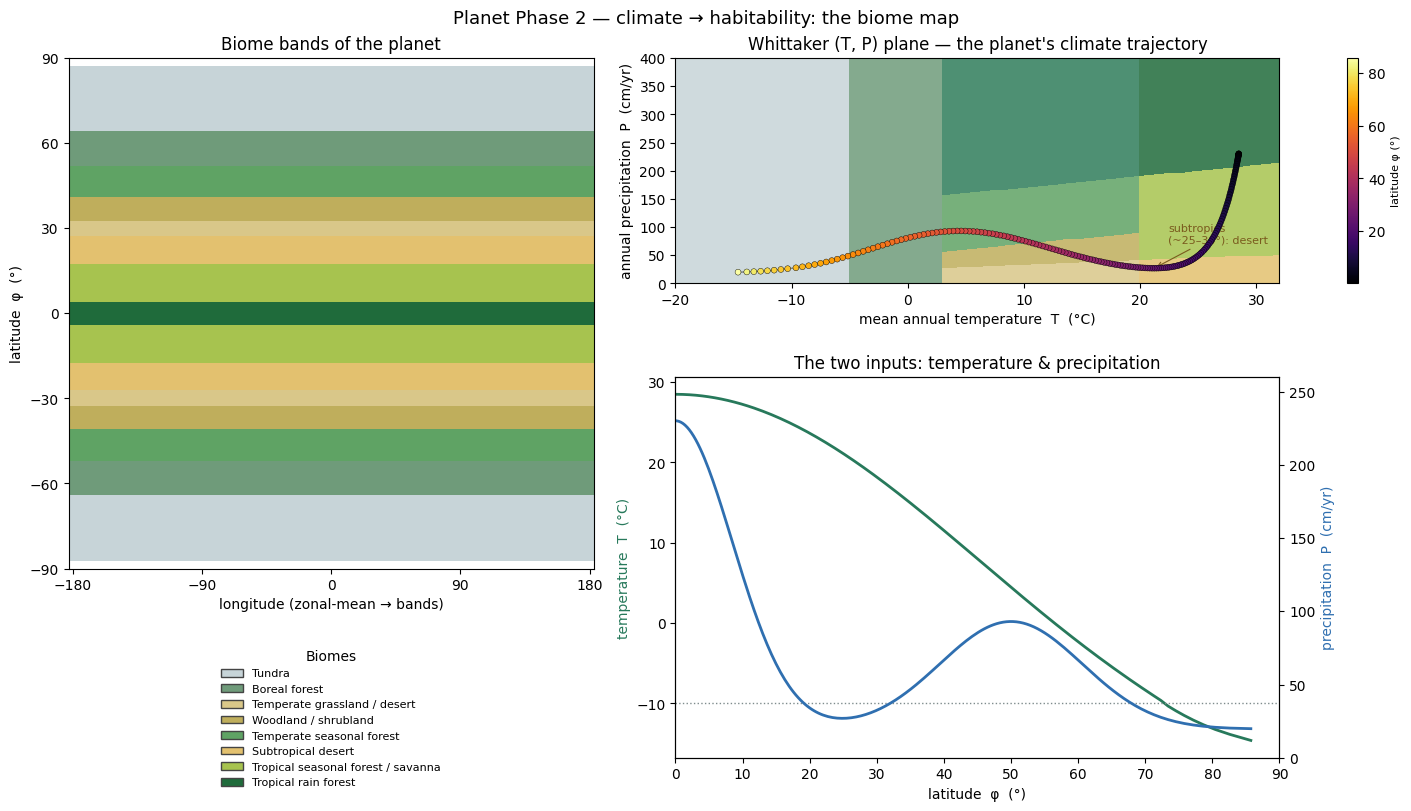

In [5]:
def biome_what_if(S0=S0_EARTH, co2_warming=0.0):
    # Climate → precip → biomes (demo_biomes.compute, the validated end-to-end map).
    # CO₂ up ≈ a drop in the OLR offset A. demo_biomes.compute uses the fine present-day n_tau internally.
    params = EBMParams(S0=float(S0), A=A_OLR - float(co2_warming))
    r = demo_biomes.compute(params)
    biomes_figure(r.state, r.precip_cm, r.codes)
    plt.show()

    # Rich "what changed + why" panel (planet.explain) in place of a terse number line.
    explain_panel(r, S0=S0, A=A_OLR - co2_warming)

# Direct render (static, banked).
biome_what_if()

In [6]:
# Live: dim/brighten the sun, and crank the greenhouse — watch the biome bands migrate poleward.
interact(
    biome_what_if,
    S0=widgets.FloatSlider(value=S0_EARTH, min=1250, max=1450, step=10,
                           description="S₀ W/m²", continuous_update=False, style=KNOB_STYLE),
    co2_warming=widgets.FloatSlider(value=0.0, min=0.0, max=12.0, step=1.0,
                                    description="CO₂ warm (−A)", continuous_update=False, style=KNOB_STYLE),
);

interactive(children=(FloatSlider(value=1365.2, continuous_update=False, description='S₀ W/m²', max=1450.0, mi…

## 4 — The winds: a second, independent engine

Everything so far runs on the **diffusion solver** — energy in, energy out, redistributed by a
parabolic transport term. But a planet also has *fluid*: an atmosphere that rotates, and the winds
that rotation organises. This is the capstone's structural job — to **build a second, independent solver engine**, a rotating **shallow-water** solver (`engines/fluid`). It shares *no*
machinery with the diffusion spine: that one is parabolic and implicit; this one is **hyperbolic and
explicit** — a wave solver, CFL-limited, on a staggered Arakawa C-grid.

Two classic rotating-fluid demonstrations show it works (`circulation` pins the planetary numbers —
Earth's `f₀ = 2Ω sin φ`, `β = 2Ω cos φ / a`, and an equivalent depth giving the midlatitude
**deformation radius** `L_R ≈ 960 km`):

- **Geostrophic adjustment** — drop an unbalanced pressure bump into a rotating fluid at rest. It
  radiates most of its height away as inertia-gravity waves and **settles into a balanced vortex of
  scale `L_R`** — the analytic *Helmholtz-adjusted* state. Rotation is what stops it from simply
  spreading flat: the pressure gradient and Coriolis come into balance (`f × u = −g∇h`).
- **A Rossby wave** — nudge a large-scale balanced undulation and it drifts **westward**, the
  signature of the planetary-vorticity gradient β, at the analytic phase speed.

The conservation diagnostics hold throughout: **mass to machine precision**, energy and potential
enstrophy **bounded** (the symmetric scheme conserves energy semi-discretely — claims stated *as
measured*, the honest Phase-3 call). The match to the analytic Helmholtz state **tightens as the grid
refines**: at the notebook's coarse `nx = 48` it lands ~2 %, while the banked full-resolution figure
(`demo_shallowwater`) reaches ~1 %. *Convergence is part of the validation, not a fudge.*

<details>
<summary><b>🌀 Going deeper — the C-grid, energy-vs-enstrophy, and why the match tightens with resolution</b> &nbsp;(click to expand)</summary>

The winds run on a **second, independent solver engine**, and it shares *no machinery* with the diffusion spine. The EBM's solver is **parabolic and implicit** (a heat equation, unconditionally stable); this one is **hyperbolic and explicit** — a wave solver on a staggered **Arakawa C-grid** (height at cell centres, velocities on the faces, the layout that represents geostrophic balance cleanly), marched with **SSP-RK3** and **CFL-limited** (the time step is capped at Courant ≈ 1 against the gravity-wave speed `√(gH)`). The planetary numbers are pinned to Earth: `f₀ = 2Ω sin φ`, `β = 2Ω cos φ / a`, and an equivalent depth `H = 1000 m` chosen (a loose calibration) so the midlatitude deformation radius `L_R = √(gH)/f₀ ≈ 960 km` matches the observed extratropical value.

**Conservation, stated as measured — the honest Phase-3 call.** Mass is conserved to **machine precision** (the flux-form continuity equation is exact by construction). Energy and potential enstrophy are reported **bounded**, not exactly conserved, and that is a real design choice: the symmetric (Sadourny-1975) scheme conserves **energy** semi-discretely but **not enstrophy** — a shallow-water discretization can be built to conserve one *or* the other (Arakawa–Lamb famously chose enstrophy), and this engine chose energy. So the diagnostics are printed as they actually behave (mass machine-exact, energy/enstrophy bounded), never dressed up as exact conservation.

**Two classic demonstrations validate it.** **Geostrophic adjustment** — drop an unbalanced pressure bump into a rotating fluid at rest; it radiates most of its height away as inertia-gravity waves and **settles into a balanced vortex of scale `L_R`**, the analytic *Helmholtz-adjusted* state where the pressure gradient and Coriolis come into balance (`f × u = −g∇h`). Rotation is what stops it from spreading flat. A **Rossby wave** — nudge a large-scale balanced undulation and it drifts **westward** at the analytic phase speed, the signature of the planetary-vorticity gradient `β`. Both are checked against their dispersion relations: the Poincaré branch `ω² = f₀² + gH·k²` for the gravity-inertia waves, and the westward Rossby branch for the slow wave.

**Convergence is part of the validation, not a fudge.** The match to the analytic Helmholtz state **tightens as the grid refines** — ~2 % at the notebook's coarse `nx = 48`, ~1 % at the banked full resolution (`demo_shallowwater`). That is the expected behaviour of a 2nd-order scheme: the discretization error shrinks with `Δx`, so the *trend* is the evidence the solver is right, and the residual is honestly reported rather than tuned to zero. (The Rossby phase speed likewise approaches its analytic value with resolution — a documented convergence property, not a bug.)

</details>

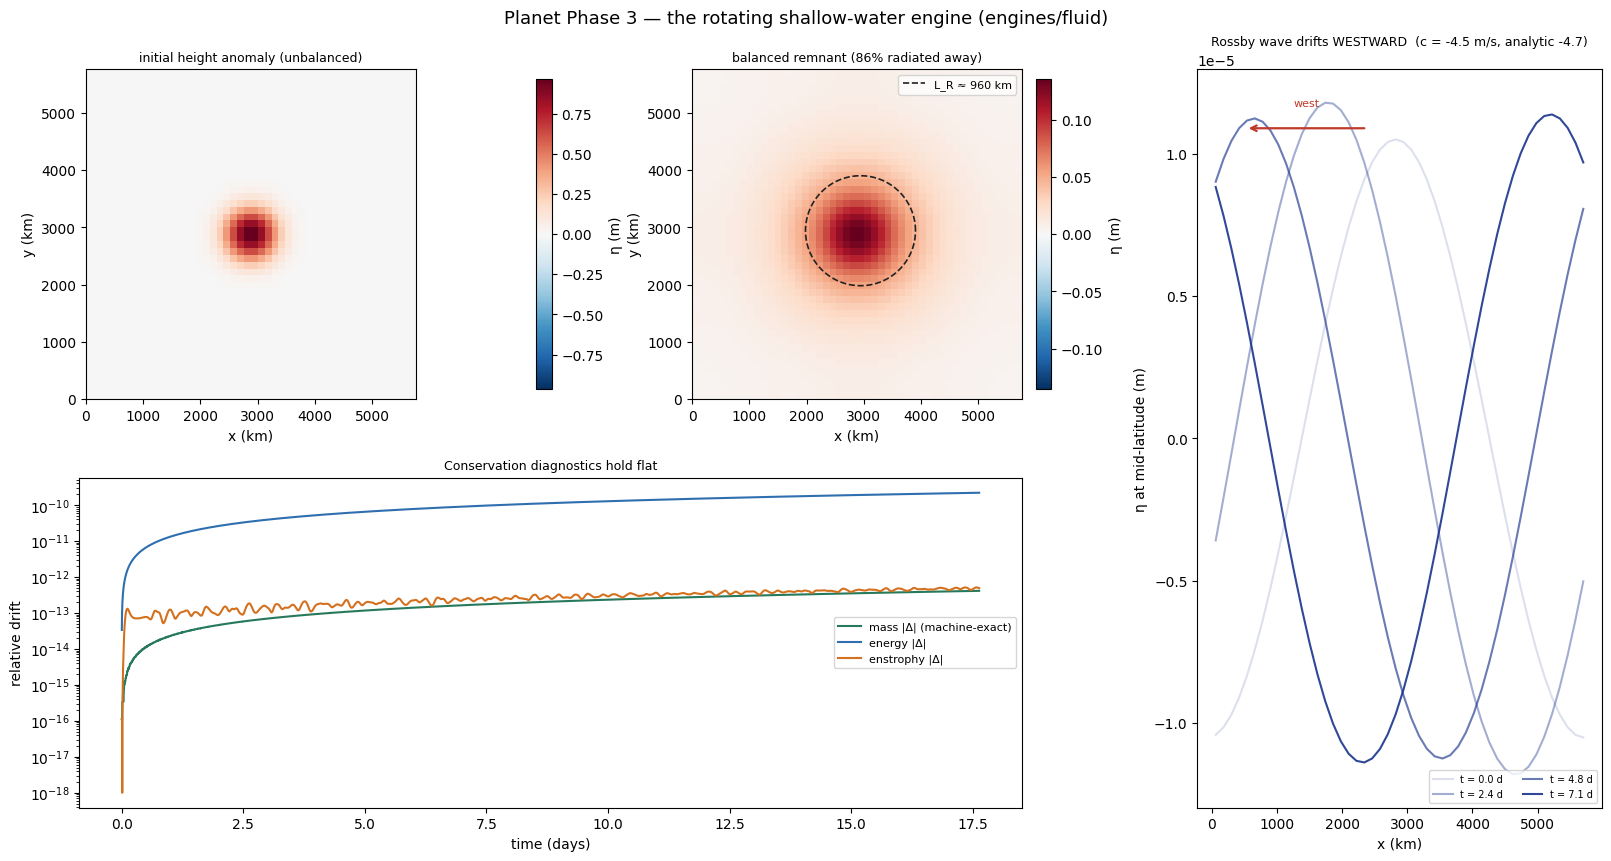

deformation radius  L_R = 960 km   (√(gH)/f₀, the midlatitude scale)
geostrophic adjustment:  86% of the bump radiated away as gravity waves;
   the balanced remnant matches the analytic Helmholtz state to 2.0% (→ ~1% at full resolution — it converges)
   mass drift 4.1e-13 (machine-exact) · energy 2.2e-10 · enstrophy 5.1e-13 (bounded)
Rossby wave:  phase speed c = -4.5 m/s WESTWARD  (analytic -4.7 m/s)


In [7]:
# A second, independent solver engine, exercised with planetary numbers (geostrophic adjustment + a Rossby wave).
# Static, banked: a ~6 s integration at nx=48 (the demo banks the full-resolution figure). No live
# slider — like §2, the story is the whole run, not a point. compute → figure → show → print.
sw = demo_shallowwater.compute(nx=48, ny=48)
shallowwater_figure(sw.adjustment, sw.rossby)
plt.show()

a, ros = sw.adjustment, sw.rossby
print(f"deformation radius  L_R = {a.L_R/1e3:.0f} km   (√(gH)/f₀, the midlatitude scale)")
print(f"geostrophic adjustment:  {100*sw.drawdown_fraction:.0f}% of the bump radiated away as gravity waves;")
print(f"   the balanced remnant matches the analytic Helmholtz state to {100*sw.helmholtz_rel_error:.1f}% "
      f"(→ ~1% at full resolution — it converges)")
print(f"   mass drift {np.abs(a.mass).max():.1e} (machine-exact) · energy {np.abs(a.energy).max():.1e} · "
      f"enstrophy {np.abs(a.enstrophy).max():.1e} (bounded)")
print(f"Rossby wave:  phase speed c = {ros.c_measured:.1f} m/s WESTWARD  (analytic {ros.c_analytic:.1f} m/s)")

## 5 — The emergent jet: coupling climate to circulation

Now the capstone's closing move — **couple the two engines**. The diffusion spine gives an
equilibrium climate; its **meridional temperature gradient** (warm equator, cold pole) *is* a
pressure/height field; hand that to the rotating shallow-water engine, and rotation organises it into
a **midlatitude westerly jet** — the same physics as the real atmosphere's jet stream. *Climate in,
circulation out.*

The forcing is composed *around* the bare engine by **operator splitting** — the same Strang idiom the EBM used for its radiation (§1), here applied to the coupler's thermal relaxation + a weak drag. One-way only in v1 (climate → circulation); the two-way feedback is the
next rung of the GCM climb (§6).

Two things make this a real result rather than a placed feature:

- **The jet is *emergent*, not positioned.** The channel brackets the whole midlatitude zone, but the
  jet lands precisely at the **EBM temperature-gradient maximum** (~45°) — move the gradient and the
  jet follows it. It sits there because the physics puts it there.
- **Geostrophic balance is the anchor.** The steady jet satisfies `f·u ≈ −g·∂h/∂y` in its core (a
  few-percent residual) — the analytic check that the coupled flow is genuinely balanced.

**Honest edges.** The engine is doubly-periodic (no walls), so the westerly is flanked by a
compensating **easterly return** — net zonal momentum is near zero. The east–west sign banding
*resembles* the general circulation, but a single dry layer does **not** reproduce the observed
westerly-dominant magnitudes (a named scope edge). And conservation is **reframed** for a
forced–dissipative system: mass stays machine-exact under forcing, while energy and enstrophy are
*not* conserved (the forcing–drag balance is what *selects* the jet) — but a **release test** switches
the forcing off and the bare engine re-confirms all three invariants *while the jet persists*, proving
it is a balanced state, not a forcing-propped artifact.

<details>
<summary><b>🌬 Going deeper — the geometry bridge, emergence, and conservation reframed</b> &nbsp;(click to expand)</summary>

The bare `engines/fluid` step carries **no forcing term**, so the climate forcing is composed *around* it by **operator splitting — the same Strang idiom** the EBM used for its radiation (§1), here driving this coupler. Each coupler step is half-forcing / full bare-engine-step / half-forcing, where the forcing half is two **exact-exponential** relaxations (so it adds no splitting instability): a **Newtonian thermal relaxation** of the height field toward the EBM-derived target, and a **weak Rayleigh drag** on the momentum with `τ_drag ≫ 1/f` so the spun-up flow settles to a *near-geostrophic* steady jet. Nothing imposes `u` — only `h_target` is imposed, and the jet is the rotation's response (a non-rotating planet would make no jet, just a stagnant high).

**The geometry bridge is the one non-obvious step.** The EBM is 1-D zonal-mean on `x = sin φ ∈ [0, 1]` (one hemisphere); the engine is a 2-D **doubly-periodic** β-plane channel with no walls. To force the periodic channel with the monotonic equator-to-pole temperature, the bridge samples `T` at the channel latitudes, forms the anomaly `θ = T − ⟨T⟩`, scales it to a height anomaly (warm → high), and then makes it **admissible**: a monotonic `θ` is *not* periodic — its `y`-seam would jump by the full equator-to-pole contrast and force a spurious giant boundary jet — so `θ` is **windowed** (a Tukey taper to matched, zero-slope edges) and made **discretely zero-mean**, giving a C¹-periodic, mass-neutral target. The channel is deliberately centred on the smooth midlatitude **baroclinic zone** and *excludes the ice-line albedo cliff* (~73°), whose sharp gradient would otherwise dominate the forcing.

**Emergence is the result, geostrophic balance the anchor.** Because the window is broad and flat across the interior, the jet lands where the **EBM gradient is steepest** (≈ the gradient maximum, ~45°) — *not* hand-placed at the channel centre; `test_coupler` proves this with a synthetic off-centre gradient whose jet follows it. The steady jet satisfies `f·u ≈ −g·∂h/∂y` in its core to a few percent — an **amplitude-independent** analytic check, distinct from Phase 3's adjustment seal.

**Conservation is reframed for a forced–dissipative system, then re-confirmed by a release test.** Under forcing, mass stays machine-exact but energy and enstrophy are *not* conserved — the forcing–drag balance is precisely what *selects* the jet. So the honest check switches the **forcing off**: the bare engine then re-confirms all three invariants *while the jet persists*, proving it is a genuinely balanced state, not a forcing-propped artifact. **The named scope edge:** the doubly-periodic channel has near-zero net zonal momentum, so the westerly is flanked by a compensating **easterly return**. That return's *existence* is geometric and physical, and the east–west–east sign banding qualitatively resembles the general circulation — but a single dry layer does **not** reproduce the observed *westerly-dominant magnitudes* (here the poleward easterly is actually the strongest band, and window-construction-dependent). So the **emergent westerly jet** is the validated claim; the return is a named edge, not a faithful trade-wind reconstruction. One-way only in v1 (climate → circulation); the two-way feedback is rung 1 of the GCM climb.

</details>

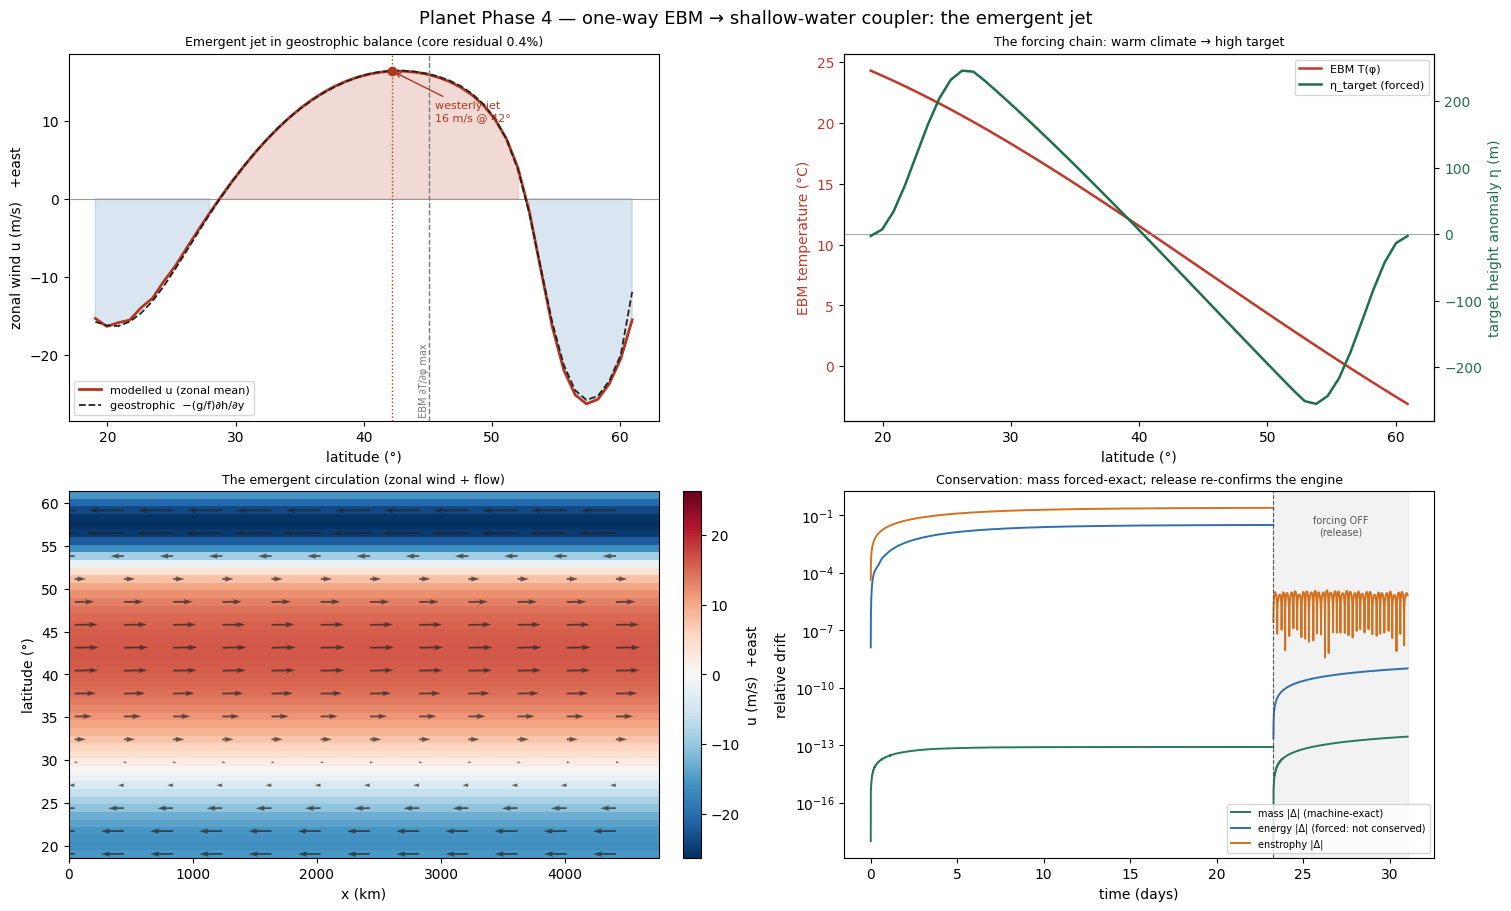

EBM climate:  T̄ 14.77 °C · ice line 72.8°
emergent westerly jet:  16.4 m/s @ 42.2°   (at the EBM ∂T/∂φ maximum 45.1° — emergent, NOT the channel centre)
   flanking easterly return -26.3 m/s · geostrophic core residual 0.4% (f·u ≈ −g ∂h/∂y, the anchor)
release test (forcing off):  mass 2.8e-13 · energy 1.0e-09 · enstrophy 1.2e-05 (engine invariants re-confirmed)
   jet persists:  16.4 → 16.4 m/s (a genuine balanced state, not forcing-propped)


In [8]:
# Couple the two engines: present-day EBM gradient → shallow-water → an emergent jet. Static, banked.
# A ~13 s spin-up at nx=48 (the demo banks the full-resolution figure + the interactive globe). Like
# §2/§4, no live slider — the plan makes the coupler computed-then-viewed (the first compute is too
# heavy for an instant remap). compute → figure → show → print (the slider-flicker order).
cp = demo_coupler.compute(nx=48, ny=48)
coupler_figure(cp.jet, cp.state)
plt.show()

j = cp.jet
print(f"EBM climate:  T̄ {cp.state.global_mean_T:.2f} °C · ice line {cp.state.ice_line_lat:.1f}°")
print(f"emergent westerly jet:  {j.jet_speed:.1f} m/s @ {j.jet_lat:.1f}°   "
      f"(at the EBM ∂T/∂φ maximum {j.gradient_peak_lat:.1f}° — emergent, NOT the channel centre)")
print(f"   flanking easterly return {j.u_profile.min():.1f} m/s · geostrophic core residual "
      f"{100*j.core_balance_residual:.1f}% (f·u ≈ −g ∂h/∂y, the anchor)")
print(f"release test (forcing off):  mass {np.abs(j.mass_release).max():.1e} · "
      f"energy {np.abs(j.energy_release).max():.1e} · enstrophy {np.abs(j.enstrophy_release).max():.1e} "
      f"(engine invariants re-confirmed)")
print(f"   jet persists:  {j.jet_speed:.1f} → {j.u_profile_release.max():.1f} m/s "
      f"(a genuine balanced state, not forcing-propped)")

## 6 — The deep end: the interactive globe

The biome map of §3 is *latitude bands* (a v1 **zonal-mean** planet). Its deep-end successor is
`planet/planetmap.py` — a **Plotly 3-D globe** painted from a layer registry, with live
sliders that recompute the climate and repaint the world. It is opt-in (a separate `[webviz]` extra:
`pip install -e .[webviz]`) so this matplotlib notebook stays light, and ships a *pin-the-schema*
exporter (`planet_spec.py`) whose round-trip-identity test is the deep end's one real correctness
property.

Its slider panel carries every knob in this notebook — including the three the **§7 design bench
also exposes**: **obliquity** (axial tilt → the insolation gradient, `obliquity.py`), the **host
star's spectrum** (a redder star → a darker ice albedo → harder to snowball), and **planet size**
(→ transport only), the exoplanet sandbox. And §5's emergent jet rides the globe as a **`vector_overlay`** — wind cones over the
temperature field — the layer registry's extensibility proven by a layer *kind* the renderer was
built generic over. *(The globe lives in `planetmap.interactive_map` behind the `[webviz]` extra, so
this matplotlib notebook **describes** it rather than embedding it; what only the globe adds over §7's
static bench is the rotatable 3-D view and the `vector_overlay` winds.)*

> **What's next — and what's already built (plan §10).** v1 is *rung 0*: a reduced, loosely-coupled
> climate. Climbing the GCM staircase from there is the project's research arc — and the first four
> rungs are **now built**, each a separately-validated module with its own test triad, showcased in
> **§8** below. **Rung 1**, the **two-way coupler**: the fluid engine advects a passive temperature
> tracer (`∫hθ` machine-conserved), the poleward-heat-transport budget closes back to the EBM
> (`transport.py`), and precipitation became **circulation-informed** — the storm track follows the
> *emergent* jet latitude (`circ_precip.py`). **Rung 2**, a **moist water cycle**: an
> energy-constrained precip rate and emergent **polar amplification** from moisture transport alone
> (`moist.py`, `moist_ebm.py`). **Rung 3**, **baroclinic eddy *turbulence*** (`baroclinic_qg.py`) —
> the saturated eddy heat flux that finally makes rung 1's reduction-to-EBM non-vacuous. **Rung 4**, a
> **spectral radiation column** (`radiation.py`) — the logarithmic CO₂ law behind the §1 greenhouse
> knob. Each still slots at the same plain-array seam; the map renderer, a pure array consumer, never
> changes. (Cheaper and parallel, still open: make the **inert elevation** layer bite — a lapse-rate
> diagnostic `T_surf = T_band − Γ·z` plus a land/ocean albedo difference.)


## 7 — Design your own world: every knob at once, save & load

The sections above turned the knobs one or two at a time. Here is the **whole console** — the climate
levers (`S₀`, the greenhouse `−A`, transport `D`) plus the three exoplanet knobs §6 introduced
(**obliquity** → the insolation gradient, the **host star's spectrum** → the ice albedo, **planet
size** → transport) — all driving the same validated chain (`planetmap.climate_params` → the EBM
climate → `demo_biomes` → the Whittaker biome map). Turn the sliders to **design a planet**; the biome
bands and the ice line respond live.

Then **name it and click 💾 Save** to write it to a file — a *planet-spec*: a versioned, self-describing
snapshot (grid + units + the painted layers + the knobs that reproduce them; `planet_spec.py`). Its
round-trip-identity test (`load(save(s)) == s`) is the deep end's one *real* correctness property, so a
saved world is a faithful, shareable artifact — hand the file to someone and they load **the exact world**.

> *(The 3-D `[webviz]` globe of §6 is the richer surface; this is the light, matplotlib **design bench** —
> all the climate knobs, the same biome map, no extra install. The globe's rotatable view and
> `vector_overlay` winds live behind the `[webviz]` extra.)*

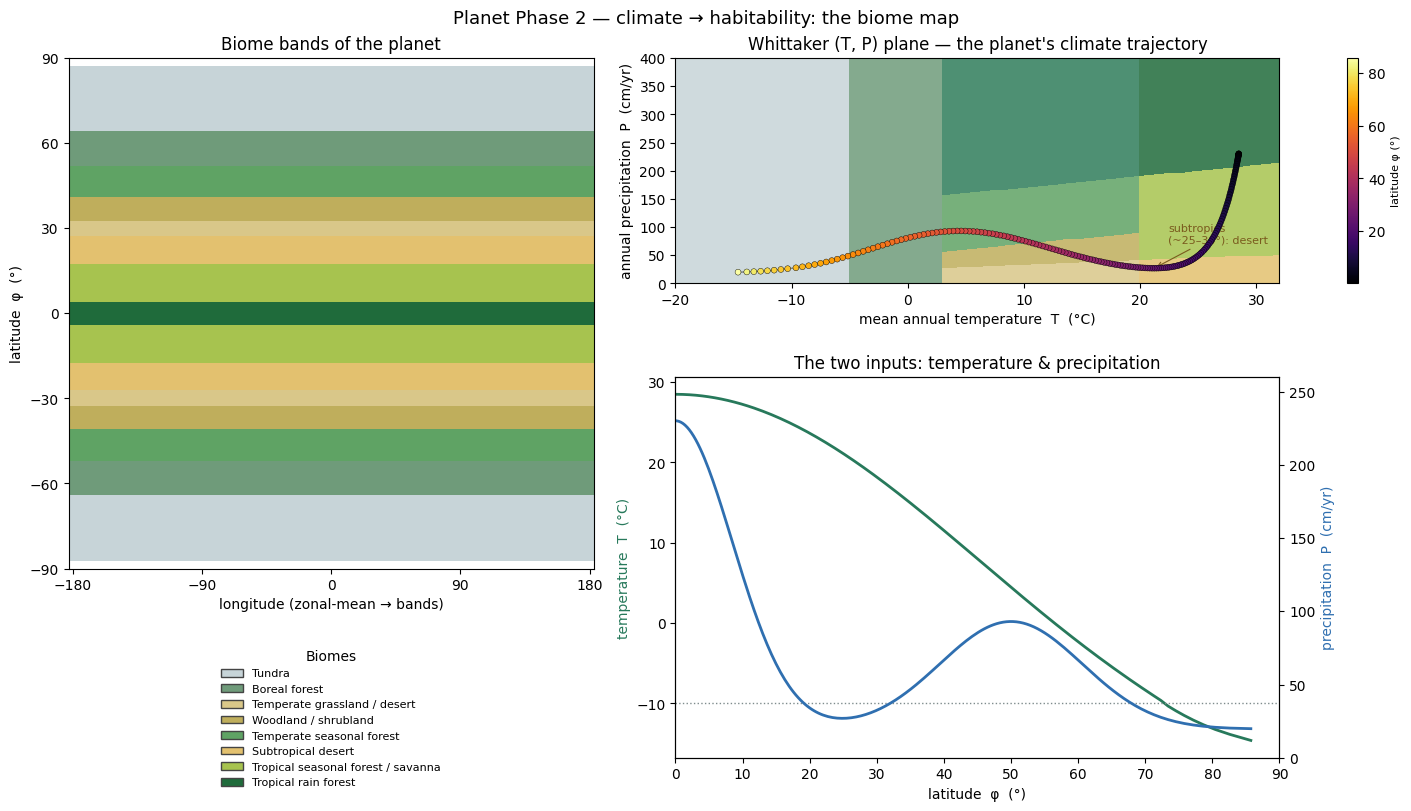

In [9]:
# The design bench. planetmap.climate_params is the SINGLE source for "knobs → EBM params" (the live
# [webviz] map rides on it too, so this bench can't drift from it); planet_spec is the *headless*
# save/load — no [webviz] needed here. Importing them pulls no Plotly (it is lazy-loaded in the globe).
from planet import planetmap, planet_spec
from planet.exoplanet import T_SUN, STAR_TEFF_MIN, SIZE_MIN
from planet.obliquity import OBLIQUITY_EARTH, OBLIQUITY_MIN, OBLIQUITY_FAITHFUL_MAX

WORLDS_DIR = Path(planet_spec.__file__).resolve().parents[1] / "outputs" / "worlds"   # gitignored (outputs/)

def design_world(S0=S0_EARTH, co2_warming=0.0, D=D_TRANSPORT,
                 obliquity=OBLIQUITY_EARTH, T_star=T_SUN, size=1.0):
    """Compose every knob -> the biome map (a *preview* — no file is written)."""
    params = planetmap.climate_params(S0=float(S0), A=A_OLR - float(co2_warming), D=float(D),
                                      obliquity_deg=float(obliquity), T_star=float(T_star), size=float(size))
    r = demo_biomes.compute(params)                       # the validated end-to-end chain (fine present-day step)
    biomes_figure(r.state, r.precip_cm, r.codes)
    plt.show()
    # Rich "what changed + why" panel — every knob narrated against present-day Earth.
    explain_panel(r, S0=S0, A=A_OLR - co2_warming, D=D,
                  obliquity_deg=obliquity, T_star=T_star, size=size)

# Direct render (static, banked) — present-day Earth from the full console. No file is written here.
design_world()

In [10]:
# The live design bench: all six knobs (continuous_update=False, style=KNOB_STYLE → recompute on release), a name box,
# and a 💾 Save button. Save fires ONLY on click — Run-All never writes a file (the smoke test stays clean).
from IPython.display import display

s0   = widgets.FloatSlider(value=S0_EARTH, min=1250, max=1450, step=10, description="S₀ W/m²", continuous_update=False, style=KNOB_STYLE)
co2  = widgets.FloatSlider(value=0.0, min=0, max=12, step=1, description="CO₂ −A", continuous_update=False, style=KNOB_STYLE)
dtr  = widgets.FloatSlider(value=D_TRANSPORT, min=0.1, max=1.2, step=0.05, description="transport D",
                           continuous_update=False, style=KNOB_STYLE, readout_format=".2f")
obl  = widgets.FloatSlider(value=OBLIQUITY_EARTH, min=OBLIQUITY_MIN, max=OBLIQUITY_FAITHFUL_MAX, step=0.5,
                           description="tilt °", continuous_update=False, style=KNOB_STYLE, readout_format=".1f")
star = widgets.FloatSlider(value=T_SUN, min=STAR_TEFF_MIN, max=8000, step=50, description="star K", continuous_update=False, style=KNOB_STYLE)
sz   = widgets.FloatSlider(value=1.0, min=SIZE_MIN, max=2.0, step=0.05, description="size R⊕",
                           continuous_update=False, style=KNOB_STYLE, readout_format=".2f")

name = widgets.Text(value="my-world", description="name")
save_btn = widgets.Button(description="💾 Save this world", button_style="success")
save_out = widgets.Output()

controls = {"S0": s0, "co2_warming": co2, "D": dtr, "obliquity": obl, "T_star": star, "size": sz}
preview = widgets.interactive_output(design_world, controls)     # live preview; renders once on creation

def _on_save(_):
    with save_out:
        save_out.clear_output()
        # build_spec captures the COMPOSED params (the §9.1 trap: a naive from_view would store the
        # un-perturbed knobs for any non-default star/size/tilt) → a re-runnable, shareable world.
        spec = planet_spec.build_spec(S0=s0.value, A=A_OLR - co2.value, D=dtr.value,
                                      obliquity_deg=obl.value, T_star=star.value, size=sz.value)
        json_path, npz_path = planet_spec.save(spec, WORLDS_DIR / (name.value or "world"))
        print(f"saved '{name.value}' → {json_path.parent.name}/{json_path.name} + {npz_path.name}   "
              f"(load it below: load_world('{name.value}'))")
save_btn.on_click(_on_save)

panel = widgets.VBox([widgets.HBox([s0, co2, dtr]), widgets.HBox([obl, star, sz]),
                      widgets.HBox([name, save_btn]), save_out])
display(panel, preview)

Output(outputs=({'output_type': 'display_data', 'data': {'text/plain': '<Figure size 1400x800 with 6 Axes>', '…

### Load a world back

A saved world is **re-runnable**: `planet_spec.load` reads the spec, `to_params()` reconstructs the
`EBMParams`, and the model reproduces the climate deterministically — *your exact world*, from its knobs.
*(The spec **also** stores the painted arrays — temperature, precipitation, biome, the ice line — but those
are the **manifest** the §6 globe and external tools consume; here we re-run from the knobs, which is why
`to_params()` is the honest "made re-runnable" path.)*

In [11]:
def load_world(stem="my-world"):
    """Load a saved planet-spec, print its knobs, re-run the model, and draw the biome map."""
    path = WORLDS_DIR / stem
    if not path.with_suffix(".json").exists():
        print(f"▸ no saved world '{stem}' in {WORLDS_DIR.name}/ yet — turn the knobs above, name it, "
              f"click 💾 Save, then re-run this cell.")
        return
    spec = planet_spec.load(path)
    p = spec.to_params()                                  # the world made re-runnable (its knobs)
    print(f"loaded '{stem}':  S₀ {p.S0:.0f} W/m² · A {p.A:.0f} · D {p.D:.3f} · "
          f"s₂ {p.s2:.3f} · ice albedo {p.ai:.3f}")
    r = demo_biomes.compute(p)                            # deterministic → reproduces the saved climate
    biomes_figure(r.state, r.precip_cm, r.codes)
    plt.show()
    print(f"   → T̄ {r.state.global_mean_T:.2f} °C · ice line {r.state.ice_line_lat:.1f}°")

load_world()    # a friendly hint until you have saved a world (no file is read or written on a fresh run)

▸ no saved world 'my-world' in worlds/ yet — turn the knobs above, name it, click 💾 Save, then re-run this cell.


### Compare two worlds: design A, design B, see exactly what changed

Two worlds side by side — *what did turning the knobs actually do?* `planet_spec.diff(a, b)` answers it
structurally: the **knobs that changed** (and only those — an exoplanet off Earth reports the *composed*
`ai`/`D`/`s₂`, never the raw star/size/tilt levers it derived them from), and the **climate that moved** —
a per-cell Δ for each field: ΔT and Δ-precip as bands, and the fraction of the planet whose **biome** flipped.

It is the *compare* sibling of the round-trip identity: `diff(a, a)` is empty, and for any two designed
worlds `bool(diff(a, b))` is exactly `a != b`. The diff is **headless** (no `[webviz]` globe needed) and
kept **honest** — if the two worlds were built at different resolutions their grids don't align, so the
per-cell Δ-maps are **skipped** (not silently shown as zero) while the knob diff still stands. Pass your own
knob dicts, or hand it two **saved** worlds (`planet_spec.load(...)`) to diff them.

Earth  →  exoplanet
knobs that changed:
   s2              -0.48 → -0.3188     dimensionless
   D               0.555 → 0.2168      W/m^2/K
   ai               0.62 → 0.4547      dimensionless
climate fields that changed:
   temperature   mean Δ  -0.42 · max |Δ|  5.50  °C
   precipitation mean Δ  -2.31 · max |Δ|  6.65  cm/yr
   biome         11.7% of the planet changed biome


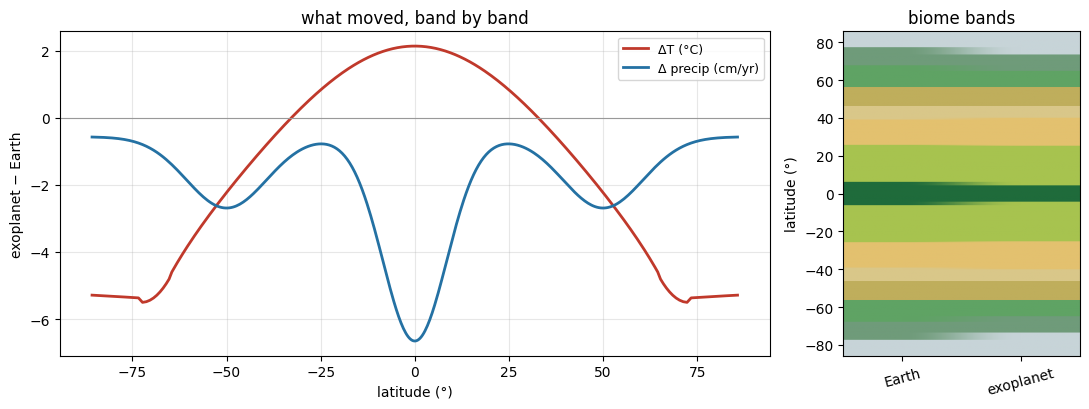

In [12]:
# Two-world diff: build A and B, then SHOW planet_spec.diff(a, b) — the knobs that changed and the
# climate that moved. Headless (no globe); the same diff the round-trip identity is the inverse of.
from planet.biomes import BIOME_COLORS
import matplotlib.colors as mcolors

def _as_spec(world, default):
    """A build_spec knob dict OR an already-built/loaded PlanetSpec → a PlanetSpec (so you can compare
    two SAVED worlds as readily as two knob dicts)."""
    world = default if world is None else world
    return world if isinstance(world, planet_spec.PlanetSpec) else planet_spec.build_spec(**world)

def compare_worlds(world_a=None, world_b=None, label_a="Earth", label_b="exoplanet"):
    """Design two worlds and show what changed from A to B (planet_spec.diff made visible)."""
    spec_a = _as_spec(world_a, {})                                        # default A: present-day Earth
    spec_b = _as_spec(world_b, dict(T_star=3500, size=1.6, obliquity_deg=35))   # B: cooler, redder, bigger, tilted
    d = planet_spec.diff(spec_a, spec_b)
    if not d:
        print(f"{label_a} and {label_b} are identical — no diff."); return

    # 1. the design inputs that changed — the COMPOSED knobs (ai/D/s₂), never the raw star/size/tilt
    #    levers they were derived from; with units, so the diff reads on its own.
    print(f"{label_a}  →  {label_b}\nknobs that changed:")
    for k, (va, vb) in d.knobs.items():
        print(f"   {k:9s} {va:11.4g} → {vb:<11.4g} {d.knob_units.get(k, '')}")
    if not d.knobs:
        print("   (none — identical climate inputs)")

    # 2. the honest grid guard: a per-cell climate Δ needs aligned grids, so an empty `fields` from
    #    mismatched resolutions must read as "not compared", NOT as "no climate change".
    if not d.grids_compatible:
        print("\n⚠ the two worlds are on different grids (different n_cells) — the climate fields are NOT "
              "cell-comparable, so the Δ-maps are skipped. Re-build both at one resolution to compare them.")
        return

    # 3. the climate that moved (per-field: a signed Δ for the numeric fields, % flipped for the biome)
    print("climate fields that changed:")
    for nm, fd in d.fields.items():
        if fd.categorical:
            print(f"   {nm:13s} {100*fd.changed_fraction:4.1f}% of the planet changed biome")
        else:
            print(f"   {nm:13s} mean Δ {fd.mean_delta:+6.2f} · max |Δ| {fd.max_abs_delta:5.2f}  {fd.units}")

    # 4. SEE it. The fields are zonal (one value per latitude band), so a column IS the Δ-profile;
    #    the biome bands of A and B side by side show the migration.
    lat = spec_a.grid.lat
    fig, (axp, axb) = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [3, 1]})
    if "temperature" in d.fields:
        axp.plot(lat, d.fields["temperature"].delta[:, 0], color="#c0392b", lw=2, label="ΔT (°C)")
    if "precipitation" in d.fields:
        axp.plot(lat, d.fields["precipitation"].delta[:, 0], color="#2471a3", lw=2, label="Δ precip (cm/yr)")
    axp.axhline(0, color="0.6", lw=0.8); axp.grid(alpha=0.3); axp.legend(loc="best", fontsize=9)
    axp.set_xlabel("latitude (°)"); axp.set_ylabel(f"{label_b} − {label_a}"); axp.set_title("what moved, band by band")

    bands = [[mcolors.to_rgb(BIOME_COLORS[Biome(int(c))]) for c in spec.view().layer("biome").data[:, 0]]
             for spec in (spec_a, spec_b)]                               # (2, n_lat, 3) → cols = the two worlds
    axb.imshow(np.transpose(np.array(bands), (1, 0, 2)), origin="lower", aspect="auto",
               extent=[-0.5, 1.5, lat[0], lat[-1]])
    axb.set_xticks([0, 1]); axb.set_xticklabels([label_a, label_b], rotation=15)
    axb.set_ylabel("latitude (°)"); axb.set_title("biome bands")
    plt.tight_layout(); plt.show()

# Present-day Earth vs a cooler, redder, bigger, more-tilted exoplanet. Pass your own knob dicts — or
# compare two SAVED worlds:  compare_worlds(planet_spec.load(WORLDS_DIR / 'a'), planet_spec.load(WORLDS_DIR / 'b'))
compare_worlds()

### On the globe: A · B · Δ (the `[webviz]` deep end)

The §6 globe paints **one** world; its comparison form paints **three** — world A, world B, and a third
globe coloured by their **difference**. Same `planet_spec.diff` underneath: A and B show the chosen field
(the biome map by default), and the Δ globe shows **where it changed** — the biome *changed-mask*, or, for a
continuous field, a diverging `B − A` centred at zero. It **reuses the §6 renderer unchanged** — the Δ is
just another layer the generic renderer paints (ADR 0004 #1) — laid into a 1×3 globe triptych.

Like §6, this matplotlib notebook **describes** the globes rather than embedding three live WebGL spheres:
`compare_globes()` below writes a standalone HTML triptych to `outputs/` (gitignored) — open it in a browser
to rotate all three. The Δ-globe *data* is `planet_spec.delta_view` (a plain layer, **headless**); only the
paint step needs the `[webviz]` extra. Pass knob dicts, or two saved worlds.

In [13]:
# The deep-end (webviz) form of the same diff: world A | world B | their Δ as three side-by-side 3-D
# globes. DEFINED here, not run on Run-All (it needs the [webviz] extra and writes an HTML file) — call
# it yourself. Like §6, this matplotlib notebook *describes* the globes; the artifact opens in a browser.
def compare_globes(world_a=None, world_b=None, active="biome", labels=("Earth", "exoplanet"), stem="comparison"):
    """A | B | Δ globes (planet_spec.delta_view → planetmap.render_comparison) → outputs/<stem>.html.

    active='biome' paints A/B as biome maps and Δ as the *changed-mask* (where the biome flipped);
    active='temperature' (or any continuous field) paints a diverging b−a ΔT globe. world_a/world_b are
    build_spec knob dicts OR saved specs (planet_spec.load(...)).
    """
    spec_a = _as_spec(world_a, {})                                            # reuse §7's dict-or-spec helper
    spec_b = _as_spec(world_b, dict(T_star=3500, size=1.6, obliquity_deg=35))
    try:
        dv = planet_spec.delta_view(spec_a, spec_b, active=active)            # headless (no Plotly)
        out = planetmap.save_comparison_html(spec_a.view(), spec_b.view(), dv,
                                             WORLDS_DIR.parent / f"{stem}.html", active=active, labels=labels)
    except ImportError:
        print("the 3-D comparison globes need the [webviz] extra — pip install -e .[webviz]"); return
    print(f"wrote the {labels[0]} | {labels[1]} | Δ globes → outputs/{out.name}  (open in a browser; rotate / zoom / hover)")
    return out

print("▸ call compare_globes() to write the A | B | Δ comparison globes (needs [webviz]); "
      "active='temperature' for a continuous ΔT globe.")

▸ call compare_globes() to write the A | B | Δ comparison globes (needs [webviz]); active='temperature' for a continuous ΔT globe.


## 8 — Up the staircase: four research rungs beyond rung 0

Everything above is **rung 0** — a reduced, loosely-coupled climate: an energy-balance temperature
profile, a *prescribed* rain pattern, a *one-way* push from climate to winds. The honest scope flags
in §3 and §5 each named the same frontier: no real water cycle, no heat carried *back* from the
eddies, a gray (not spectral) greenhouse. Climbing the **GCM staircase** past rung 0 is the project's
research arc, and §6 promised it was coming. This section shows the **first four rungs, now built** —
each a *separate, independently-validated* module (its own analytic-limit / conservation /
published-benchmark triad), and each one a claim made at an **honest altitude**, with its overreach
pinned rather than papered over.

Unlike §1–§5, these cells mostly **embed the demo's banked figure** (the publication render saved by
`python -m planet.demo_…`) rather than re-rendering live — the rung-3 turbulence run alone is minutes
of integration. Where the compute is cheap the **numbers are still recomputed live** below each
figure (they are deterministic — they match the banked render). The figures remain *reach*; the
triads in `planet/tests/` are the evidence.


### 8.1 — Rung 2: a moist water cycle (wet-get-wetter, dry-get-drier)

§3's rain was one pattern scaled by **one** Clausius–Clapeyron amplitude (~7 %/K) — so under warming
*everything* wettens, **including the deserts**, the opposite of what is observed. Rung 2 splits that
single rate in two, the **Held & Soden (2006) "rich-get-richer"** structure: the global *mean*
precipitation is **energy-constrained** to a slower **~2.5 %/K** (the atmosphere can only radiate away
so much latent heat), while the wet−dry *anomaly* sharpens at the faster ~7 %/K moisture rate. The wet
bands intensify, and the **subtropical deserts dry** — the contrast grows faster than the mean.

**At the honest altitude** (a better *prescribed* parameterization, not a derived field): the split
*direction* is the prescription, and the two rates are cited closures. What is **structurally exact**
is the mean-zero anomaly split (so the area-mean really does scale at the energy rate) and the clean
reduction back to rung 0 when the two rates coincide. **The pinned overreach:** scaling *every*
below-mean latitude down at the C–C rate also **dries the poles**, the wrong sign — observed
high-latitude precip *increases* (poleward moisture transport, a dynamic rung-3+ effect). So this is a
*tropical/subtropical* idealization, right where the deserts are, wrong at the poles — annotated on
the figure, not hidden. Rung 0's uniform-C–C precip stays the default; this is opt-in.

*(`moist.wet_get_wetter` lives in the rung-2 module; the demo's printout below tags it "rung-1
evidence" because it refines the rung-1 rain **pattern** — the new ingredient it adds, the
energy-constrained mean rate, is the rung-2 step.)*



Wet-get-wetter, dry-get-drier (rung 1, the thermodynamic contrast split)

  warming:           +6 K above present
  ITCZ peak:           +91.6 cm/yr  (wet-get-wetter — the wet band intensifies)
  desert @ 25°:     wet-get-wetter  -13.4 cm/yr  (DRY-get-drier)
                     rung-0 uniform  +13.9 cm/yr  (WETTENS — the flaw this fixes)
  global mean ⟨P⟩:    78.9 → 92.9 cm/yr (scales at the energy rate ~2.5 %/K, not C–C 7 %/K)
    => the SPLIT direction is prescribed; what is exact is the mean-zero anomaly + the reductions.



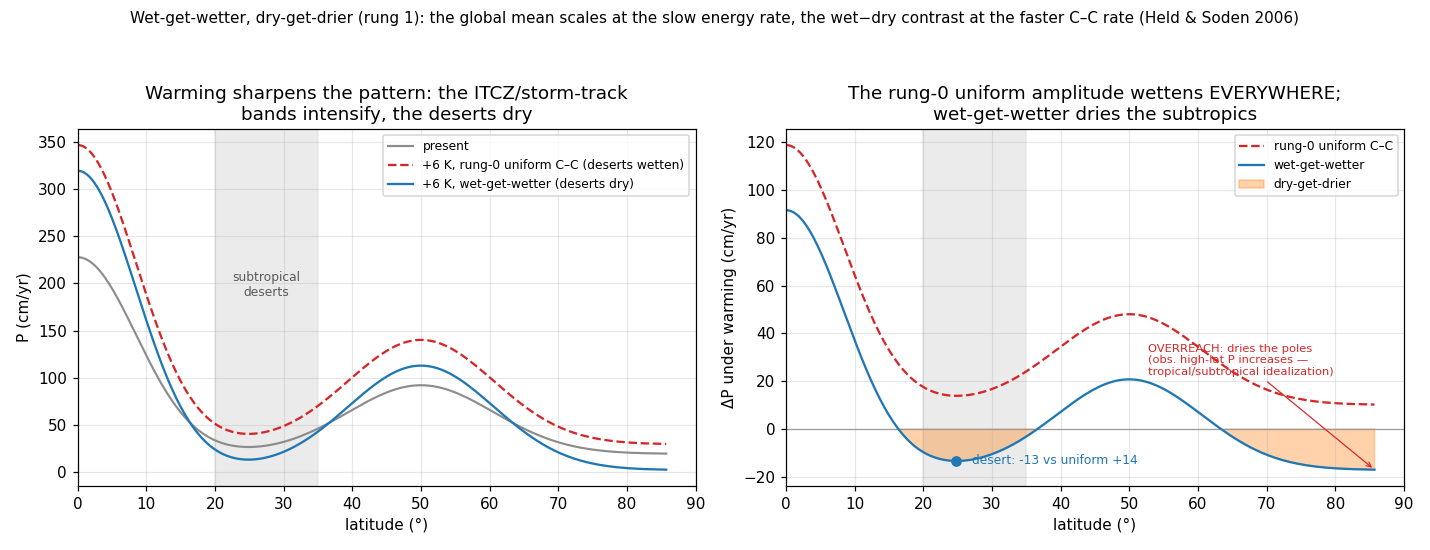

In [14]:
# Rung 2 — the wet-get-wetter / dry-get-drier contrast split (numbers live; figure is the banked render).
from planet import demo_wet_get_wetter
from IPython.display import Image

w = demo_wet_get_wetter.compute()          # the present-day climate warmed by +6 K
demo_wet_get_wetter.print_summary(w)       # live, deterministic — matches the banked figure below

# The demo's banked render (python -m planet.demo_wet_get_wetter): panel 1 the precip fields, panel 2
# the warming response ΔP — uniform C–C wettens everywhere, the split dries the subtropics (and, the
# named overreach, the poles).
Image(filename=str(demo_wet_get_wetter.DOCS_FIGURE))


### 8.2 — Rung 2.5: emergent polar amplification (from moisture alone)

The poles warm faster than the tropics — *polar amplification*. The usual first explanation is the
ice-albedo feedback (the §2 cliff), but rung 2.5 shows a **second, independent** cause with the ice
feedback switched **off** entirely. Let the heat-transport diffusivity carry **moist static energy**,
not just sensible heat: warm tropical air holds much more latent heat, so its **effective diffusivity
`D_eff(T) = D_s·(1 + β(T))` grows where it is warm** (`β ∝ L·dq_sat/dT`). Warm the planet uniformly
and the now-stronger tropical transport exports more of that warmth poleward — the poles warm more.

The control is the cleanest possible: a **dry** EBM (constant `D`) warmed by the same forcing heats
**exactly uniformly** (transport of a uniform field is zero) — `PA ≈ 1`, the null. The **moist** EBM
**redistributes** that *same* pinned global-mean warming `⟨ΔT⟩ = ΔA/B` poleward. Read it honestly as
**redistribution around a conserved mean**, not added pole heat: the *direction* is banked and the
attribution is exact (freeze `D_eff` and `PA` collapses to 1), but the *magnitude* is loose — it rides
the recalibrated sensible `D_s`, and the single-endpoint ratio (~2.05) is the generous read of the
less-flattering area-band ratio (~1.80). Both are honest "polar amplification"; the band number is
carried so the endpoint is not mistaken for *the* number.


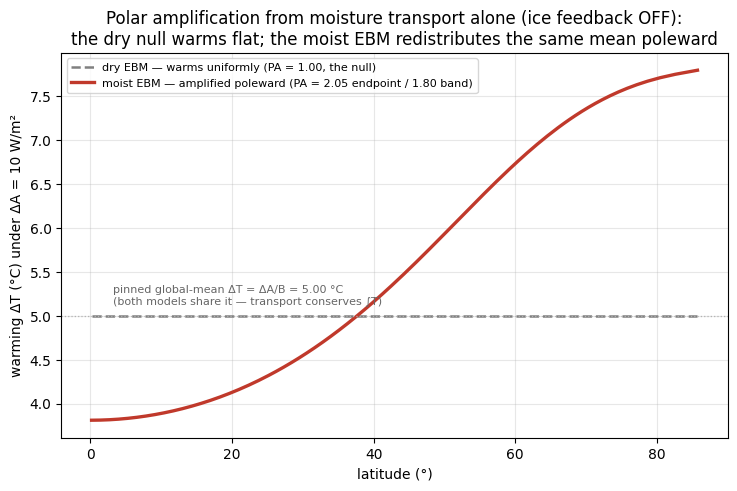

global-mean warming (pinned, both models): 5.000 °C
dry EBM:   pole/equator 1.000  (≈ 1 — uniform; the clean null, no amplification)
moist EBM: pole/equator 2.05  (endpoint) / 1.80 (60°+ vs 30°- band)
   the redistributed polar excess above the mean: +2.80 °C


In [15]:
# Rung 2.5 — warm a dry vs a moist EBM by the same uniform forcing; the moist one amplifies at the poles.
from planet import moist_ebm
import numpy as np
import matplotlib.pyplot as plt

pa = moist_ebm.polar_amplification()       # dt-free Picard solve; ice feedback OFF — moisture only

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.plot(pa.phi, pa.delta_T_dry, "--", color="0.5", lw=1.8,
        label=f"dry EBM — warms uniformly (PA = {pa.pa_dry:.2f}, the null)")
ax.plot(pa.phi, pa.delta_T_moist, "-", color="#c0392b", lw=2.4,
        label=f"moist EBM — amplified poleward (PA = {pa.pa_moist:.2f} endpoint / {pa.pa_moist_band:.2f} band)")
ax.axhline(pa.mean_delta_T, color="0.7", lw=0.9, ls=":")
ax.annotate(f"pinned global-mean ΔT = ΔA/B = {pa.mean_delta_T:.2f} °C\n(both models share it — transport conserves ∫T)",
            (2, pa.mean_delta_T), textcoords="offset points", xytext=(6, 8), fontsize=8, color="0.4")
ax.set_xlabel("latitude (°)")
ax.set_ylabel(f"warming ΔT (°C) under ΔA = {pa.dA:.0f} W/m²")
ax.set_title("Polar amplification from moisture transport alone (ice feedback OFF):\n"
             "the dry null warms flat; the moist EBM redistributes the same mean poleward")
ax.legend(fontsize=8, loc="upper left")
ax.grid(alpha=0.3)
plt.show()

print(f"global-mean warming (pinned, both models): {pa.mean_delta_T:.3f} °C")
print(f"dry EBM:   pole/equator {pa.pa_dry:.3f}  (≈ 1 — uniform; the clean null, no amplification)")
print(f"moist EBM: pole/equator {pa.pa_moist:.2f}  (endpoint) / {pa.pa_moist_band:.2f} (60°+ vs 30°- band)")
print(f"   the redistributed polar excess above the mean: {pa.polar_excess:+.2f} °C")


### 8.3 — Rung 3: baroclinic eddy *turbulence* (the saturated heat flux)

Rung 1 carried heat back to the EBM, but on the smooth midlatitude gradient that flux was nearly
**reversible** (mixing efficiency ~10⁻³ — almost vacuous). The fix is the real machine of midlatitude
heat transport: **baroclinic instability**. A vertically-sheared flow over a rotating planet is
unstable; the growing waves roll up into **eddies** that flux warm air poleward and cold air
equatorward. Rung 3 builds it as a **two-layer quasi-geostrophic** turbulence model (`baroclinic_qg`)
— the leap past rung 1's passive tracer is that the layer interface *is* the dynamical temperature, so
heat transport is intrinsic.

**The bet, and why it was not free.** A down-gradient, *irreversible* flux is **guaranteed** for any
sustained baroclinic state (it is the available-potential-energy → eddy-energy conversion), so the
flux sign alone proves nothing. The bet is won only by **showing genuine turbulence** — and it is: the
kinetic-energy spectrum peaks **below** the injection scale (an **inverse cascade** to the box scale,
`v'_rms ≫ U_s`), broadband and continuous, with coherent vortices and rolled-up PV filaments. A steady
wave would peak *at* the injection scale with discrete harmonics. With that established, the flux is
**irreversible at fraction ~0.96–1.0** (vs rung 1's ~0.1) at an **order-unity** dimensionless mixing
efficiency `κ/(v'L_d) ~ O(1)` (vs rung 1's ~10⁻³) — so rung 1's reduction-to-EBM is **finally
non-vacuous**. What is banked is **dimensionless + qualitative**; the dimensional `κ` is box- and
drag-dependent (it shifts ~45 % with resolution), so a value landing in Earth's range is coincidental,
not a calibrated prediction. The linear leg is tight: the QG dispersion matches the analytic two-layer
**Phillips** problem to ~10⁻¹⁵ and recovers the **Charney–Stern** critical shear `U_crit = β/F`.


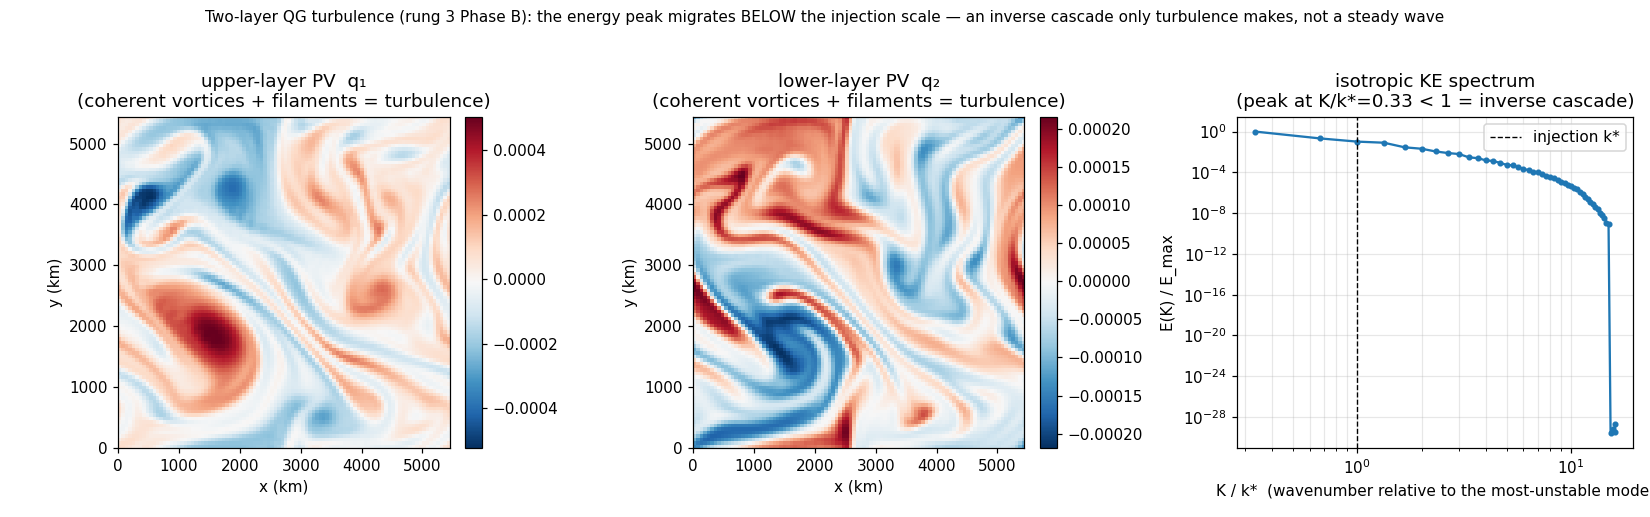

In [16]:
# Rung 3 — the saturated two-layer QG turbulence run is ~minutes, so this is the demo's banked render
# (python -m planet.demo_baroclinic_qg). The headline diagnostics are in the text above; the figure:
#   left/centre — upper- and lower-layer PV (coherent vortices + filaments = turbulence, not a wave),
#   right       — the isotropic KE spectrum, energy peak migrated BELOW the injection k* (inverse cascade).
from planet import demo_baroclinic_qg
from IPython.display import Image

Image(filename=str(demo_baroclinic_qg.DOCS_FIGURE))


### 8.4 — Rung 4: the spectral greenhouse — why the CO₂ knob is *logarithmic*

The §1 greenhouse knob is a single OLR offset `A` — a **gray** (band-independent) greenhouse. It gets
the *sign* of CO₂ forcing right but the *shape* wrong: a gray absorber **saturates**, each doubling
adding *less* than the last (it pushes the whole emission spectrum to the cold upper atmosphere). The
observed law is **logarithmic** — Myhre+ (1998): `ΔF = 5.35·ln(C/C₀)`, a **constant ≈ 3.7 W m⁻² per
doubling**, the relationship every climate-sensitivity estimate rests on.

Rung 4 recovers it from the one missing ingredient: **spectral structure**. Resolve the CO₂ 15-µm band
into bins whose absorption falls off **exponentially in the wings**. The band centre is already
saturated, so new forcing comes only from the wings — and an exponential wing's emission level spreads
by a *constant* spectral width per doubling, giving **constant ΔF per doubling = the log law**.
Flatten the wing and the forcing saturates again, so the exponential wing is provably the whole story.
**At the honest altitude:** the *functional form* (logarithmic) is the win; the *magnitude* (~4 W m⁻²
per doubling) rides the band parameters, calibrated to **order**, not line-by-line spectroscopy. And
it is range-limited — linear below where the centre saturates, saturating again far above; the
realistic 0.5×–8× window sits in the flat logarithmic middle.



Spectral-band log law: why CO₂ forcing is logarithmic, not saturating (rung 4 slice)

  per-doubling ΔF (W/m²):
    gray (band-indep.) : 0.5→1×: 34.2  1→2×: 48.4  2→4×: 52.9  4→8×: 41.2  8→16×: 25.4  16→32×: 20.0   → DECREASING (saturating)
    spectral (exp wings): 0.5→1×: 4.53  1→2×: 4.52  2→4×: 4.51  4→8×: 4.50  8→16×: 4.49  16→32×: 4.48   → CONSTANT (logarithmic)

  spectral flat-middle 0.5×–8×: 4.52 W/m²/doubling (spread 1.005×)
  Myhre 5.35·ln2             : 3.71 W/m²/doubling (order-validated, not tuned)
  analytic τ=1 wing formula  : 3.54 W/m²/doubling (sharp limit; column sits ~20–30% above)



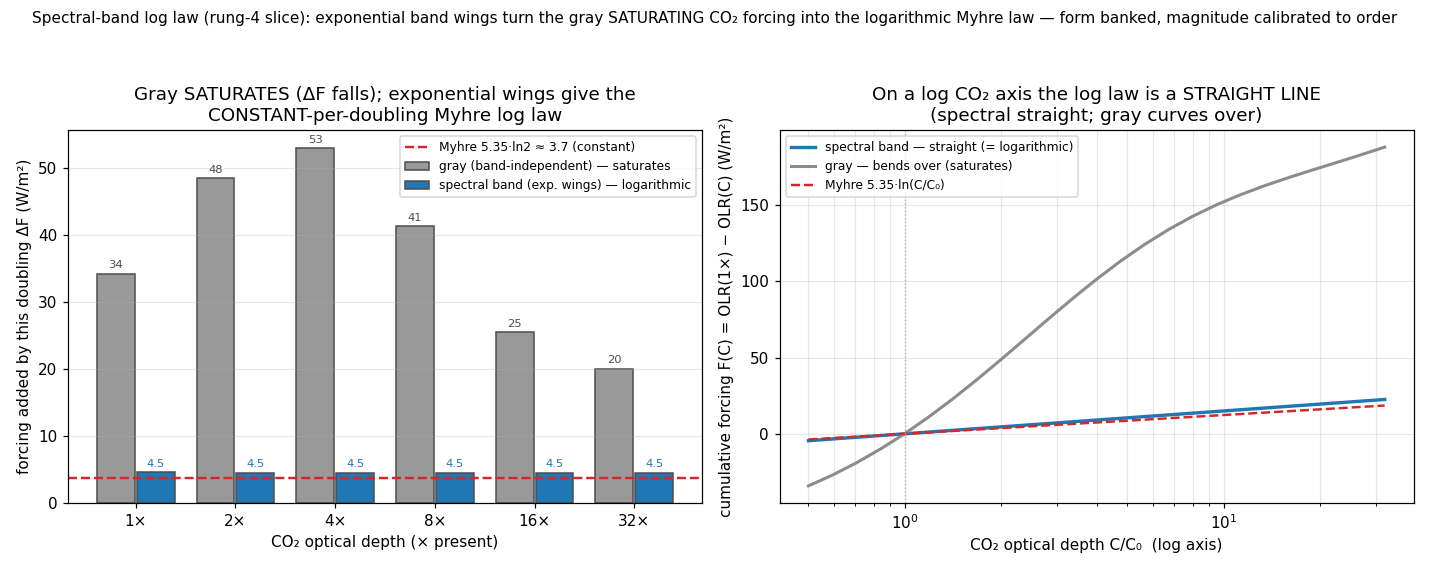

In [17]:
# Rung 4 — the gray (saturating) vs spectral (logarithmic) CO2 forcing (numbers live; figure banked).
from planet import demo_spectral_band
from IPython.display import Image

r = demo_spectral_band.compute()           # analytic — fast; deterministic, matches the banked figure
demo_spectral_band.print_summary(r)

# The demo's banked render (python -m planet.demo_spectral_band): panel 1 ΔF per doubling — gray falls
# (saturates), the spectral band is flat at the Myhre constant; panel 2 cumulative F(C) on a log CO2
# axis — the log law is a straight line where gray bends over.
Image(filename=str(demo_spectral_band.DOCS_FIGURE))


## Where the numbers come from

Nothing here is fit in the notebook — every value is produced by a module validated in isolation,
each behind its own test triad (an analytic limit, a conservation/consistency law, a published
benchmark):

| Step | Module | Anchored to |
|---|---|---|
| Climate (EBM) | `ebm`, `albedo` | North (1975) **two-mode** analytic solution (~2nd order in Δx); global energy balance ⟨S(1−α)⟩ = A + B⟨T⟩ (net-TOA ~0); climlab present-day ice line ~70° |
| Snowball | `albedo`, `demo_snowball` | hysteresis **existence & structure** (two branches, a catastrophic jump, re-melt later than freeze); Voigt–Marotzke GCM dimming threshold 6–9% |
| Precipitation | `precip` | ITCZ-wet / subtropics-dry / midlat-wet / poles-dry band structure; **monotone** ⟨P⟩(T̄); Clausius–Clapeyron ~7 %/K (moisture capacity) |
| Biomes | `biomes` | **total partition** (area fractions sum to 1); independent canonical **probe points**; observed equator→pole band ordering |
| Winds (shallow-water) | `circulation`, `demo_shallowwater` | gravity-wave √(gH) + **Poincaré dispersion** ω²=f₀²+gHk²; **geostrophic adjustment** to the analytic Helmholtz state over `L_R` (~1% at full res); mass machine-exact, energy/enstrophy bounded; **westward** Rossby phase speed |
| Emergent jet (coupler) | `coupler`, `demo_coupler` | **geostrophic balance** of the emergent jet (`f·u ≈ −g∂h/∂y`); jet at the EBM gradient maximum (*emergent*); the **release test** (forcing off → engine invariants re-confirmed, the jet persists) |
| Two-way coupler — rung 1 (§8) | `transport`, `circ_precip` | reduction to the EBM via the κ→D bridge (`D = C·κ/a²`); `∫hθ` machine-conserved passive tracer; the storm-track centre tracks the *emergent* jet latitude (not the gradient peak) |
| Moist water cycle — rungs 2–2.5 (§8.1–8.2) | `moist`, `moist_ebm` | mean-zero anomaly split (area-mean scales at the energy-constrained ~2.5 %/K; Held & Soden 2006); emergent polar amplification ~1.8–2.1× from `D_eff(T)` alone, **dry-EBM null exactly uniform**, freeze-`D_eff` attribution → PA = 1 |
| Baroclinic turbulence — rung 3 (§8.3) | `baroclinic_qg` | analytic two-layer **Phillips** dispersion (~10⁻¹⁵) + **Charney–Stern** `U_crit = β/F`; inverse-cascade KE spectrum (peak below injection `k*`); down-gradient, irreversible (~0.96–1.0) flux at `κ/(v'L_d) ~ O(1)` |
| Spectral radiation — rung 4 (§8.4) | `radiation` | the **Myhre** logarithmic law `5.35·ln(C/C₀)` ≈ 3.7 W m⁻²/doubling from exponential band wings; reduces to the gray column when the wing is flattened |

The transport term reuses a **general-purpose `engines/diffusion` solver, unchanged** — here as a sphere's pole-to-equator heat transport — and the radiation is grafted on with **Strang operator splitting** (the §5 coupler reuses that same splitting idiom). The winds of §4–5 run on a **second, independent** engine — the rotating shallow-water solver, **built here**, sharing no machinery with the diffusion spine. The §8 research rungs each add their own separately-validated module (the two-layer QG turbulence of rung 3 is a third solver again). Per [ADR 0002](../docs/decisions/0002-visualization-and-ux.md)
the figures above are *reach*, not evidence: the triads test the numbers, then we draw them.

Run the full validation suite for planet with `python -m pytest`, or the demos for the
publication-quality static figures (`python -m planet.demo_snowball`,
`python -m planet.demo_biomes`, `python -m planet.demo_shallowwater`,
`python -m planet.demo_coupler`; and the §8 rungs: `python -m planet.demo_wet_get_wetter`,
`python -m planet.demo_baroclinic_qg`, `python -m planet.demo_spectral_band`).
